# Stage 5: Computational Performance Benchmarking

**Objective.** Stages 1-4 froze three representations of the same ~100-patient FHIR dataset --
`R0` (canonical FHIR R4), `R1` (structure-preserving normalized), `R2` (aggressively flattened) --
and established that `W1`-`W3` are feasible and exactly fidelity-preserving in all three
representations, while `W4` is feasible only in `R0`/`R1` (R2 does not retain
`Encounter.period.end`). This stage does not revisit any of that: representations, transformation
rules, and workload definitions are frozen inputs.

Stage 5 asks a different question: **given that a representation is analytically valid for a
workload, what does it cost, computationally, to use it?** Five dimensions are measured and kept
separate throughout (no composite performance score is constructed):

1. storage footprint of the persistent representation;
2. one-time R0 -> R1 / R0 -> R2 transformation cost;
3. cost of loading an already-materialized representation into memory;
4. query-only execution cost, given the representation is already loaded;
5. end-to-end analytical access cost, from persistent storage to final query result.

All benchmarking code, the frozen transformation logic it reuses, and every raw measurement are
reproducible from this notebook alone.


## 1. Experimental Environment

Reproducibility metadata is captured first and saved to `results/stage5/benchmark_environment.json`.
Only information obtainable programmatically and reliably is recorded; nothing about the hardware
is guessed.


In [1]:
import json
import math
import os
import platform
import random
import re
import sys
import time
import warnings
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from IPython.display import display

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
    return start.resolve()


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

from lib.stage5_transform import (
    discover_dataset_dir, ref_id, load_r0, load_r0_filtered, first_coding,
    build_r1_tables, build_r2_tables,
)
from lib.stage5_workloads import (
    SNOMED, RXNORM, BRONCHITIS_CODE, SELECTED_MED_SYSTEM, SELECTED_MED_CODE, THRESHOLD_HOURS,
    read_csv_str, load_r1_tables_from_csv, load_r2_tables_from_csv, norm_id, matching_concept_ids,
    w1_r0, w1_r1, w1_r2, w2_r0, w2_r1, w2_r2, w3_r0, w3_r1, w3_r2, w4_r0, w4_r1,
    REQUIRED_R0_TYPES, REQUIRED_R1_TABLES, REQUIRED_R2_TABLES,
)

STAGE3_DIR = REPO_ROOT / "results" / "stage3"
STAGE4_DIR = REPO_ROOT / "results" / "stage4"
RESULTS_DIR = REPO_ROOT / "results" / "stage5"
FIG_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 100)
warnings.filterwarnings("ignore", category=FutureWarning)


In [2]:
def try_or_none(fn):
    try:
        return fn()
    except Exception:
        return None


cpu_freq = try_or_none(lambda: psutil.cpu_freq()._asdict())

benchmark_environment = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "random_seed": RANDOM_SEED,
    "os": {
        "system": platform.system(),
        "release": platform.release(),
        "platform": platform.platform(),
    },
    "machine_architecture": platform.machine(),
    "processor": platform.processor(),
    "python_version": platform.python_version(),
    "python_implementation": platform.python_implementation(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "matplotlib_version": matplotlib.__version__,
    "psutil_version": psutil.__version__,
    "logical_cpu_count": os.cpu_count(),
    "physical_cpu_count": try_or_none(lambda: psutil.cpu_count(logical=False)),
    "cpu_freq_mhz": cpu_freq,
    "total_memory_gib": round(psutil.virtual_memory().total / 1024**3, 2),
    "storage_medium": "not reliably determinable without privileged/vendor-specific APIs on this platform -- not reported to avoid guessing",
    "notes": [
        "cpu_freq_mhz is reported as returned by psutil; on Windows this may reflect the OS-reported "
        "nominal/current frequency rather than actual per-core turbo behavior during benchmarking.",
        "Absolute timing values below are specific to this machine/OS/Python build and are not portable "
        "performance claims; only within-run relative comparisons (R0 vs R1 vs R2) are interpreted.",
    ],
}

with open(RESULTS_DIR / "benchmark_environment.json", "w", encoding="utf-8") as f:
    json.dump(benchmark_environment, f, indent=2)

pd.DataFrame([
    {"item": "OS", "value": benchmark_environment["os"]["platform"]},
    {"item": "Machine architecture", "value": benchmark_environment["machine_architecture"]},
    {"item": "Python", "value": benchmark_environment["python_version"]},
    {"item": "pandas", "value": benchmark_environment["pandas_version"]},
    {"item": "NumPy", "value": benchmark_environment["numpy_version"]},
    {"item": "Logical CPUs", "value": benchmark_environment["logical_cpu_count"]},
    {"item": "Physical CPUs", "value": benchmark_environment["physical_cpu_count"]},
    {"item": "Total memory (GiB)", "value": benchmark_environment["total_memory_gib"]},
    {"item": "Random seed", "value": RANDOM_SEED},
    {"item": "Timestamp (UTC)", "value": benchmark_environment["timestamp_utc"]},
])


,item,value
0,OS,Windows-11-10.0.26200-SP0
1,Machine architecture,AMD64
2,Python,3.14.6
3,pandas,3.0.6
4,NumPy,2.5.3
5,Logical CPUs,22
6,Physical CPUs,16
7,Total memory (GiB),31.47
8,Random seed,42
9,Timestamp (UTC),2026-09-27T08:03:38+00:00


## 2. Dataset and Representation Integrity

`R0` is re-derived with the exact dataset-discovery and parsing logic used in Stages 1/3/4
(`lib/stage5_transform.py`, extracted verbatim -- see Section 3 below for the extraction note).
Resource counts, and the R1/R2 tables this notebook builds itself, are checked against the frozen
`results/stage3` and `results/stage4` outputs before anything is benchmarked. If any check fails,
this notebook stops rather than benchmarking an inconsistent representation.


In [3]:
EXPECTED_COUNTS = {"Patient": 109, "Encounter": 5635, "Condition": 3540, "Observation": 46305, "MedicationRequest": 3858}

dataset_dir = discover_dataset_dir(REPO_ROOT)
all_resources, resources_by_target_type = load_r0(dataset_dir)
actual_counts = {rt: len(resources_by_target_type[rt]) for rt in EXPECTED_COUNTS}

integrity_rows = []
for rt, expected in EXPECTED_COUNTS.items():
    integrity_rows.append({"check": f"R0 resource count [{rt}]", "expected": expected, "actual": actual_counts[rt], "match": actual_counts[rt] == expected})

with open(STAGE3_DIR / "stage3_summary.json", encoding="utf-8") as f:
    stage3_summary = json.load(f)
with open(STAGE4_DIR / "workload_definitions.json", encoding="utf-8") as f:
    frozen_workload_definitions = json.load(f)
with open(STAGE4_DIR / "stage4_summary.json", encoding="utf-8") as f:
    stage4_summary = json.load(f)

frozen_result_sets = pd.read_csv(STAGE4_DIR / "result_sets.csv", dtype=str)


def frozen_set(workload_id, representation):
    m = (frozen_result_sets.workload_id == workload_id) & (frozen_result_sets.representation == representation)
    return set(frozen_result_sets.loc[m, "result_id"])


integrity_rows.append({
    "check": "Stage 4 W2 selected medication == frozen RxNorm 106892",
    "expected": "106892", "actual": SELECTED_MED_CODE, "match": SELECTED_MED_CODE == "106892",
})
integrity_rows.append({
    "check": "Stage 4 W4/R2 recorded as not_feasible",
    "expected": True, "actual": stage4_summary["w4_infeasible_in_r2"], "match": stage4_summary["w4_infeasible_in_r2"] is True,
})

integrity_df = pd.DataFrame(integrity_rows)
integrity_df.to_csv(RESULTS_DIR / "integrity_check.csv", index=False)
assert integrity_df["match"].all(), integrity_df[~integrity_df["match"]]
print(f"Integrity check passed: {len(integrity_df)}/{len(integrity_df)} checks match frozen Stage 1/3/4 outputs.")
integrity_df


Integrity check passed: 7/7 checks match frozen Stage 1/3/4 outputs.


,check,expected,actual,match
0,R0 resource count [Patient],109,109,True
1,R0 resource count [Encounter],5635,5635,True
2,R0 resource count [Condition],3540,3540,True
3,R0 resource count [Observation],46305,46305,True
4,R0 resource count [MedicationRequest],3858,3858,True
5,Stage 4 W2 selected medication == frozen RxNorm 106892,106892,106892,True
6,Stage 4 W4/R2 recorded as not_feasible,True,True,True


## 3. Benchmarking Methodology

**Frozen-logic reuse.** The R0 discovery/parsing procedure and the R0 -> R1 -> R2 transformation
rules are notebook-only code in `notebooks/01_fhir_dataset_audit.ipynb` and
`notebooks/03_representation_transformations.ipynb`, so they cannot be `import`-ed directly. They
have been extracted **verbatim** (same field access, same branching, same helper functions) into
`lib/stage5_transform.py`; the frozen `W1`-`W4` query logic from
`notebooks/04_analytical_fidelity.ipynb` is likewise extracted into `lib/stage5_workloads.py`. This
is a refactor for reuse only -- Section 2 above and Section 5 below confirm the extracted code
reproduces the frozen resource counts, R1/R2 tables, and `W1`-`W4` result sets exactly. No
transformation rule or workload definition is changed.

**Timing scenarios**, kept strictly separate:

- **Query-only (Scenario A).** The representation is already resident in memory (R0: parsed
  resource lists; R1/R2: already-loaded DataFrames). The timed region contains *only* the
  operations the workload needs to compute its result -- no file I/O, no JSON/CSV parsing.
- **End-to-end (Scenario B).** Timed from the persistent representation on disk (R0: FHIR JSON
  files; R1/R2: the frozen `results/stage3/*.csv` files) to the final result set. Only the files a
  given workload actually needs are read (documented per workload/representation in Section 6);
  irrelevant resource types/tables are never force-loaded to inflate a representation's cost.
- **Transformation cost (Section 6).** The one-time cost of producing R1/R2 from R0, using the
  same extracted-but-behaviorally-identical `build_r1_tables` / `build_r2_tables` functions.

**Warm-up and repetitions.** Every feasible workload/representation/scenario combination is warmed
up 5 times (same function that is later measured) before any measured repetition; warm-up runs are
discarded, never included in the statistical summary. Query-only benchmarking uses >= 30 measured
repetitions; end-to-end benchmarking uses >= 10. Because several query-only calls complete in
low single-digit milliseconds or less, a deterministic calibration probe (one untimed call) picks a
batch size so each *measured* timing covers >= 5 ms of wall-clock time (`elapsed_ns / batch_size`
recovers the per-query cost); the same calibration rule is applied uniformly to every
workload/representation pair, so no combination is batched differently to flatter it.

**Timer.** `time.perf_counter_ns()` (monotonic, nanosecond resolution) is used throughout. All raw
per-repetition measurements are saved (`results/stage5/raw_timings.csv`); summaries report median
and IQR (skew-robust), not only the mean.

**Correctness guard.** Before any timing, every feasible query implementation is executed once and
compared against the frozen Stage 4 result sets (Section 5). During measured repetitions, the
result produced by the final call of every batch is re-checked against the frozen set; any
mismatch invalidates that repetition rather than being silently averaged in.

**Filesystem-cache limitation.** The OS file cache is not cleared between repetitions (no
privileged operation is used to do so). End-to-end repetitions after the first should therefore be
read as *application-level repeated access* timings, not true cold-disk-I/O timings; the first
repetition is flagged separately (`first_run` column) in the raw data.


## 4. Storage Footprint

Physical storage footprint of each *persistent* representation, measured directly from the files
on disk (not loaded from a precomputed summary). R0 is the source FHIR JSON directory; R1/R2 are
the frozen `results/stage3/r1_*.csv` / `r2_*.csv` tables. Notebooks, figures, result summaries and
Stage 5's own outputs are excluded.

CSV is a serialization choice made in Stage 3, not an intrinsic property of R1/R2 as logical
representations -- a columnar or binary store could plausibly change these numbers substantially.
The values below describe *this experimental serialization only*.


In [4]:
def dir_footprint(files):
    files = list(files)
    total_bytes = sum(f.stat().st_size for f in files)
    return {"n_files": len(files), "total_bytes": total_bytes, "mib": total_bytes / 1024**2}


r0_files = sorted(dataset_dir.glob("*.json"))
r1_files = sorted(STAGE3_DIR.glob("r1_*.csv"))
r2_core_files = sorted(f for f in STAGE3_DIR.glob("r2_*.csv") if f.name != "r2_observation_component_schema.csv")
r2_metadata_files = sorted(STAGE3_DIR.glob("r2_observation_component_schema.csv"))

storage_rows = []
r0_fp = dir_footprint(r0_files)
r1_fp = dir_footprint(r1_files)
r2_fp = dir_footprint(r2_core_files)
r2_meta_fp = dir_footprint(r2_metadata_files)

for rep, fp, note in [
    ("R0", r0_fp, "canonical FHIR R4 Bundle JSON files (" + str(dataset_dir.relative_to(REPO_ROOT)) + ")"),
    ("R1", r1_fp, "all r1_*.csv tables (structure-preserving normalized representation)"),
    ("R2", r2_fp, "all r2_*.csv core data tables (patient/encounter/condition/medication_request/observation)"),
]:
    storage_rows.append({
        "representation": rep, "n_files": fp["n_files"], "total_bytes": fp["total_bytes"], "mib": round(fp["mib"], 3),
        "relative_size_vs_r0": round(fp["total_bytes"] / r0_fp["total_bytes"], 4),
        "relative_size_vs_r1": round(fp["total_bytes"] / r1_fp["total_bytes"], 4),
        "files_included": note,
    })

storage_df = pd.DataFrame(storage_rows)
storage_df.to_csv(RESULTS_DIR / "storage_footprint.csv", index=False)

print(f"R2 auxiliary metadata (r2_observation_component_schema.csv, describes the R2 component-pivot "
      f"schema but is not itself analytical data): {r2_meta_fp['mib']:.4f} MiB -- excluded from the R2 "
      f"core figure above and reported separately here for transparency.")
print()
print("NOTE: these figures describe the current CSV serialization of R1/R2, not a universal storage "
      "property of the logical representation (e.g. a columnar/binary store could differ substantially).")
storage_df


R2 auxiliary metadata (r2_observation_component_schema.csv, describes the R2 component-pivot schema but is not itself analytical data): 0.0030 MiB -- excluded from the R2 core figure above and reported separately here for transparency.

NOTE: these figures describe the current CSV serialization of R1/R2, not a universal storage property of the logical representation (e.g. a columnar/binary store could differ substantially).


,representation,n_files,total_bytes,mib,relative_size_vs_r0,relative_size_vs_r1,files_included
0,R0,111,386150705,368.262,1.0000,6.7674,canonical FHIR R4 Bundle JSON files (synthea_sample_data_fhir_latest)
1,R1,12,57060116,54.417,0.1478,1.0000,all r1_*.csv tables (structure-preserving normalized representation)
2,R2,5,16718227,15.944,0.0433,0.2930,all r2_*.csv core data tables (patient/encounter/condition/medication_request/observation)


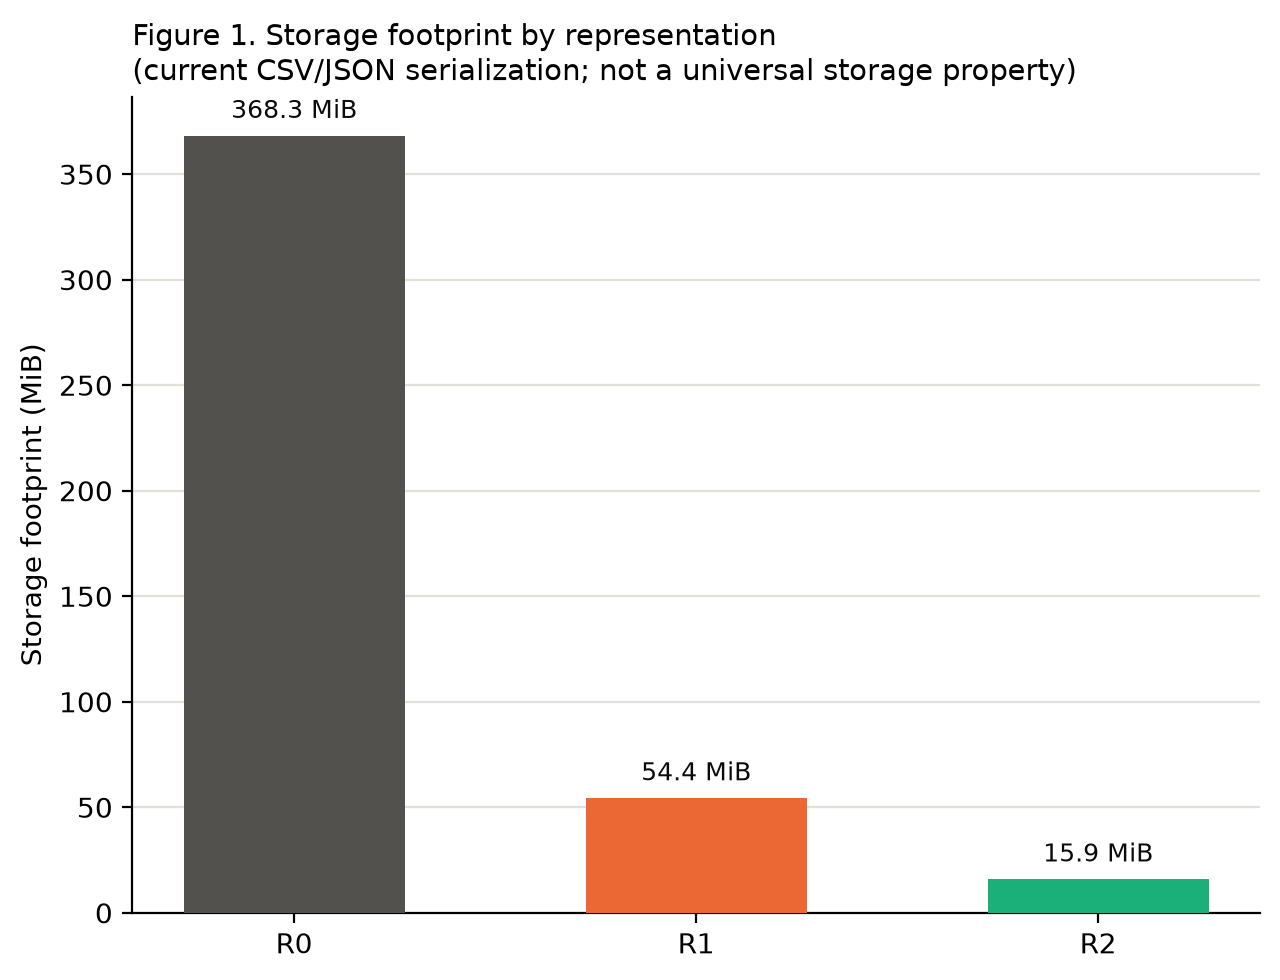

In [5]:
# Figure 1: storage footprint by representation (current CSV serialization)
COLOR_R0, COLOR_R1, COLOR_R2 = "#52514e", "#eb6834", "#1baf7a"
COLOR_MAP = {"R0": COLOR_R0, "R1": COLOR_R1, "R2": COLOR_R2}
INK_PRIMARY, INK_MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

REPRESENTATIONS_ORDER = ["R0", "R1", "R2"]
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=200)
heights = [float(storage_df.loc[storage_df.representation == rep, "mib"].iloc[0]) for rep in REPRESENTATIONS_ORDER]
bars = ax.bar(REPRESENTATIONS_ORDER, heights, color=[COLOR_MAP[r] for r in REPRESENTATIONS_ORDER], width=0.55, zorder=3)
for rep, h in zip(REPRESENTATIONS_ORDER, heights):
    ax.text(rep, h + max(heights) * 0.015, f"{h:.1f} MiB", ha="center", va="bottom", fontsize=9, color=INK_PRIMARY)

ax.set_ylabel("Storage footprint (MiB)")
ax.set_title("Figure 1. Storage footprint by representation\n(current CSV/JSON serialization; not a universal storage property)", fontsize=10.5, loc="left")
ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure1_storage_footprint.png", dpi=200, bbox_inches="tight")
plt.show()


## 5. Transformation Cost

One-time cost of producing R1 and R2 from R0, using the frozen `build_r1_tables` / `build_r2_tables`
functions from `lib/stage5_transform.py` (verbatim extraction of
`notebooks/03_representation_transformations.ipynb`, Sections 2-15). No faster alternative
transformation is substituted.

**A real dependency, not an artifact of this benchmark:** in the frozen Stage 3 notebook, the R2
build reuses two R1 artifacts as-is (`r2_patient` is a column slice of `r1_patient_df`; the
corrected `reason_condition_id` foreign key is validated against `r1_condition_df`'s id set).
R2 is therefore not independently constructible from R0 in the current pipeline. Rather than
inventing an R2-only shortcut that bypasses this dependency, `R0 -> R2` is measured as the full
pipeline cost (`R0` parse + `build_r1_tables` (in-memory only, not persisted) + `build_r2_tables`
+ writing the R2 CSVs). `R0 -> R1` is measured as `R0` parse + `build_r1_tables` + writing the R1
CSVs. `R0` parsing is shared and reported once per repetition since both pipelines require it.


In [6]:
N_TRANSFORM_REPS = 5
TMP_TRANSFORM_DIR = RESULTS_DIR / "_tmp_transform_output"
TMP_TRANSFORM_DIR.mkdir(exist_ok=True)

transform_records = []
for rep in range(N_TRANSFORM_REPS):
    t0 = time.perf_counter_ns()
    all_res_rep, rbt_rep = load_r0(dataset_dir)
    t1 = time.perf_counter_ns()
    r0_parse_ns = t1 - t0

    t0 = time.perf_counter_ns()
    r1_tables_rep = build_r1_tables(rbt_rep)
    t1 = time.perf_counter_ns()
    r1_compute_ns = t1 - t0

    t0 = time.perf_counter_ns()
    for name, df in r1_tables_rep.items():
        df.to_csv(TMP_TRANSFORM_DIR / f"{name}.csv", index=False)
    t1 = time.perf_counter_ns()
    r1_write_ns = t1 - t0

    t0 = time.perf_counter_ns()
    r2_tables_rep = build_r2_tables(rbt_rep, all_res_rep, r1_tables_rep)
    t1 = time.perf_counter_ns()
    r2_compute_ns = t1 - t0

    t0 = time.perf_counter_ns()
    for name, df in r2_tables_rep.items():
        df.to_csv(TMP_TRANSFORM_DIR / f"{name}.csv", index=False)
    t1 = time.perf_counter_ns()
    r2_write_ns = t1 - t0

    transform_records.append({
        "repetition": rep, "r0_parse_ns": r0_parse_ns, "r1_compute_ns": r1_compute_ns, "r1_write_ns": r1_write_ns,
        "r2_compute_ns": r2_compute_ns, "r2_write_ns": r2_write_ns,
        "total_r0_to_r1_ns": r0_parse_ns + r1_compute_ns + r1_write_ns,
        "total_r0_to_r2_ns": r0_parse_ns + r1_compute_ns + r2_compute_ns + r2_write_ns,
    })

for f in TMP_TRANSFORM_DIR.glob("*.csv"):
    f.unlink()
TMP_TRANSFORM_DIR.rmdir()

transform_df = pd.DataFrame(transform_records)
for c in transform_df.columns:
    if c.endswith("_ns"):
        transform_df[c.replace("_ns", "_ms")] = transform_df[c] / 1e6

transform_cost_summary = pd.DataFrame([
    {
        "pipeline": "R0_parse", "phase": "transformation_compute_time",
        "median_ms": transform_df["r0_parse_ns"].median() / 1e6, "n_reps": N_TRANSFORM_REPS,
    },
    {
        "pipeline": "R0_to_R1", "phase": "transformation_compute_time",
        "median_ms": transform_df["r1_compute_ns"].median() / 1e6, "n_reps": N_TRANSFORM_REPS,
    },
    {
        "pipeline": "R0_to_R1", "phase": "serialization_write_time",
        "median_ms": transform_df["r1_write_ns"].median() / 1e6, "n_reps": N_TRANSFORM_REPS,
    },
    {
        "pipeline": "R0_to_R1", "phase": "total_materialization_time",
        "median_ms": transform_df["total_r0_to_r1_ns"].median() / 1e6, "n_reps": N_TRANSFORM_REPS,
    },
    {
        "pipeline": "R0_to_R2", "phase": "transformation_compute_time (incremental R1->R2)",
        "median_ms": transform_df["r2_compute_ns"].median() / 1e6, "n_reps": N_TRANSFORM_REPS,
    },
    {
        "pipeline": "R0_to_R2", "phase": "serialization_write_time",
        "median_ms": transform_df["r2_write_ns"].median() / 1e6, "n_reps": N_TRANSFORM_REPS,
    },
    {
        "pipeline": "R0_to_R2", "phase": "total_materialization_time (full pipeline, R1 not persisted)",
        "median_ms": transform_df["total_r0_to_r2_ns"].median() / 1e6, "n_reps": N_TRANSFORM_REPS,
    },
])
transform_cost_summary["median_ms"] = transform_cost_summary["median_ms"].round(2)
transform_cost_summary.to_csv(RESULTS_DIR / "transformation_cost.csv", index=False)
transform_df.to_csv(RESULTS_DIR / "transformation_cost_raw.csv", index=False)
transform_cost_summary


,pipeline,phase,median_ms,n_reps
0,R0_parse,transformation_compute_time,8246.73,5
1,R0_to_R1,transformation_compute_time,4428.90,5
2,R0_to_R1,serialization_write_time,1049.92,5
3,R0_to_R1,total_materialization_time,13186.55,5
4,R0_to_R2,transformation_compute_time (incremental R1->R2),591.83,5
5,R0_to_R2,serialization_write_time,443.88,5
6,R0_to_R2,"total_materialization_time (full pipeline, R1 not persisted)",13069.85,5


## 6. Frozen Workload Definitions

`W1`-`W4` exactly as frozen in `results/stage4/workload_definitions.json`; no matching rule, code,
or threshold is redefined here. The `W2` medication (RxNorm `106892`) is loaded from that frozen
file, not rediscovered.


In [7]:
workload_overview = pd.DataFrame([
    {"workload_id": wl, "name": defn["name"], "research_question": defn["research_question"], "result_set_unit": defn["result_set_unit"]}
    for wl, defn in frozen_workload_definitions.items()
])
display(workload_overview)

print("W1 concept:", frozen_workload_definitions["W1"]["concept"])
print("W2 selected medication:", frozen_workload_definitions["W2"]["selected_medication"]["system"],
      frozen_workload_definitions["W2"]["selected_medication"]["code"])
print("W4 threshold_hours:", frozen_workload_definitions["W4"]["duration_distribution_r0"]["threshold_hours"])
assert frozen_workload_definitions["W2"]["selected_medication"]["code"] == SELECTED_MED_CODE
assert frozen_workload_definitions["W1"]["concept"]["code"] == BRONCHITIS_CODE


,workload_id,name,research_question,result_set_unit
0,W1,Single-concept clinical cohort,Identify patients with Acute bronchitis.,unique Patient IDs
1,W2,Cross-resource clinical cohort,Patients with Acute bronchitis who also have a MedicationRequest (medicationCodeableConcept) for...,unique Patient IDs
2,W3,Relationship-aware temporal query,Patients whose MedicationRequest.reasonReference->Condition was authored on/after that Condition...,unique Patient IDs
3,W4,Secondary temporal-semantics query,Encounters whose duration exceeds 24 hours.,unique Encounter IDs


W1 concept: {'system': 'http://snomed.info/sct', 'code': '10509002', 'display': 'Acute bronchitis (disorder)'}
W2 selected medication: http://www.nlm.nih.gov/research/umls/rxnorm 106892
W4 threshold_hours: 24.0


## 7. Benchmark Functions

Loading and query logic are kept in separate functions so query-only and end-to-end scenarios are
unambiguous. `REQUIRED_R0_TYPES` / `REQUIRED_R1_TABLES` / `REQUIRED_R2_TABLES`
(`lib/stage5_workloads.py`) document exactly which FHIR resource types / CSV tables each
workload/representation pair needs -- no workload ever force-loads an irrelevant resource type or
table to inflate or deflate a representation's cost. There is no `("W4", "R2")` entry anywhere
below: `W4` is not feasible in `R2` (Stage 4 finding) and is never approximated.


In [8]:
WORKLOADS = ["W1", "W2", "W3", "W4"]
REPRESENTATIONS = ["R0", "R1", "R2"]

QUERY_DISPATCH = {
    ("W1", "R0"): lambda d: w1_r0(d["rbt"]),
    ("W1", "R1"): lambda d: w1_r1(d["r1_condition"], d["r1_coding"]),
    ("W1", "R2"): lambda d: w1_r2(d["r2_condition"]),
    ("W2", "R0"): lambda d: w2_r0(d["rbt"]),
    ("W2", "R1"): lambda d: w2_r1(d["r1_condition"], d["r1_coding"], d["r1_medication_request"]),
    ("W2", "R2"): lambda d: w2_r2(d["r2_condition"], d["r2_medication_request"]),
    ("W3", "R0"): lambda d: w3_r0(d["rbt"]),
    ("W3", "R1"): lambda d: w3_r1(d["r1_medication_request"], d["r1_condition"]),
    ("W3", "R2"): lambda d: w3_r2(d["r2_medication_request"], d["r2_condition"]),
    ("W4", "R0"): lambda d: w4_r0(d["rbt"]),
    ("W4", "R1"): lambda d: w4_r1(d["r1_encounter"]),
    # ("W4", "R2") intentionally absent: not feasible.
}
FEASIBLE_COMBOS = [(wl, rep) for wl in WORKLOADS for rep in REPRESENTATIONS if (wl, rep) in QUERY_DISPATCH]


def load_data(workload_id, representation):
    """Load only the persistent files/resources this workload/representation pair needs."""
    if representation == "R0":
        return {"rbt": load_r0_filtered(dataset_dir, REQUIRED_R0_TYPES[workload_id])}
    if representation == "R1":
        return load_r1_tables_from_csv(STAGE3_DIR, REQUIRED_R1_TABLES[workload_id])
    if representation == "R2":
        return load_r2_tables_from_csv(STAGE3_DIR, REQUIRED_R2_TABLES[workload_id])
    raise ValueError(representation)


required_files_doc = []
for wl, rep in FEASIBLE_COMBOS:
    if rep == "R0":
        needed = ", ".join(f"{t} (from every *.json bundle -- Bundle.entry interleaves all types)" for t in REQUIRED_R0_TYPES[wl])
    elif rep == "R1":
        needed = ", ".join(f"{t}.csv" for t in REQUIRED_R1_TABLES[wl])
    else:
        needed = ", ".join(f"{t}.csv" for t in REQUIRED_R2_TABLES[wl])
    required_files_doc.append({"workload_id": wl, "representation": rep, "required_resources_or_files": needed})
required_files_df = pd.DataFrame(required_files_doc)
required_files_df


,workload_id,representation,required_resources_or_files
0,W1,R0,Condition (from every *.json bundle -- Bundle.entry interleaves all types)
1,W1,R1,"r1_condition.csv, r1_coding.csv"
2,W1,R2,r2_condition.csv
3,W2,R0,"Condition (from every *.json bundle -- Bundle.entry interleaves all types), MedicationRequest (f..."
4,W2,R1,"r1_condition.csv, r1_coding.csv, r1_medication_request.csv"
5,W2,R2,"r2_condition.csv, r2_medication_request.csv"
6,W3,R0,"Condition (from every *.json bundle -- Bundle.entry interleaves all types), MedicationRequest (f..."
7,W3,R1,"r1_medication_request.csv, r1_condition.csv"
8,W3,R2,"r2_medication_request.csv, r2_condition.csv"
9,W4,R0,Encounter (from every *.json bundle -- Bundle.entry interleaves all types)


## 8. Correctness Verification

Every feasible implementation is executed once against its minimally-loaded data and compared to
the frozen Stage 4 result sets. Benchmarking does not proceed if any check fails.


In [9]:
correctness_rows = []
for wl, rep in FEASIBLE_COMBOS:
    data = load_data(wl, rep)
    computed = QUERY_DISPATCH[(wl, rep)](data)
    expected = frozen_set(wl, rep)
    correctness_rows.append({
        "workload_id": wl, "representation": rep, "computed_size": len(computed), "frozen_size": len(expected),
        "matches_stage4_exactly": computed == expected,
    })

correctness_df = pd.DataFrame(correctness_rows)
assert correctness_df["matches_stage4_exactly"].all(), correctness_df[~correctness_df["matches_stage4_exactly"]]
print(f"Correctness verification passed: {len(correctness_df)}/{len(correctness_df)} feasible "
      f"workload/representation pairs reproduce the frozen Stage 4 result set exactly.")
correctness_df


Correctness verification passed: 11/11 feasible workload/representation pairs reproduce the frozen Stage 4 result set exactly.


,workload_id,representation,computed_size,frozen_size,matches_stage4_exactly
0,W1,R0,41,41,True
1,W1,R1,41,41,True
2,W1,R2,41,41,True
3,W2,R0,4,4,True
4,W2,R1,4,4,True
5,W2,R2,4,4,True
6,W3,R0,95,95,True
7,W3,R1,95,95,True
8,W3,R2,95,95,True
9,W4,R0,52,52,True


## 9. Query-Only Benchmark (Scenario A)

Each feasible workload/representation pair is loaded once (outside the timed region), warmed up 5
times, then measured for >= 30 repetitions using `time.perf_counter_ns()`. A deterministic
calibration probe picks a batch size so each measured repetition covers roughly 5 ms of wall time;
the reported `per_query_ms` divides the batch's elapsed time by its batch size. Every measured
result is re-checked against the frozen Stage 4 result set (`correctness_verified`).


In [10]:
CALIBRATION_TARGET_NS = 5_000_000
MAX_BATCH_SIZE = 500
N_WARMUP = 5
N_QUERY_REPS = 30


def calibrate_batch_size(fn):
    t0 = time.perf_counter_ns()
    fn()
    t1 = time.perf_counter_ns()
    single_ns = max(t1 - t0, 1)
    return min(MAX_BATCH_SIZE, max(1, math.ceil(CALIBRATION_TARGET_NS / single_ns)))


def run_timed_batches(fn, batch_size, n_reps):
    records = []
    for rep in range(n_reps):
        t0 = time.perf_counter_ns()
        result = None
        for _ in range(batch_size):
            result = fn()
        t1 = time.perf_counter_ns()
        records.append({"repetition": rep, "elapsed_ns": t1 - t0, "result": result})
    return records


raw_timing_rows = []

for wl, rep in FEASIBLE_COMBOS:
    data = load_data(wl, rep)
    expected = frozen_set(wl, rep)
    fn = (lambda d=data, wl=wl, rep=rep: QUERY_DISPATCH[(wl, rep)](d))

    for _ in range(N_WARMUP):
        fn()

    batch_size = calibrate_batch_size(fn)
    batches = run_timed_batches(fn, batch_size, N_QUERY_REPS)
    for b in batches:
        raw_timing_rows.append({
            "scenario": "query_only", "workload_id": wl, "representation": rep,
            "repetition": b["repetition"], "batch_size": batch_size,
            "elapsed_ns": b["elapsed_ns"], "elapsed_ms": b["elapsed_ns"] / 1e6,
            "per_query_ms": (b["elapsed_ns"] / batch_size) / 1e6,
            "result_set_size": len(b["result"]), "correctness_verified": b["result"] == expected,
            "first_run": b["repetition"] == 0, "warmup_or_measured": "measured",
        })

print(f"Query-only benchmarking complete: {len(FEASIBLE_COMBOS)} workload/representation pairs, "
      f"{N_WARMUP} warm-ups + {N_QUERY_REPS} measured repetitions each.")


Query-only benchmarking complete: 11 workload/representation pairs, 5 warm-ups + 30 measured repetitions each.


In [11]:
query_only_df = pd.DataFrame([r for r in raw_timing_rows if r["scenario"] == "query_only"])
assert query_only_df["correctness_verified"].all(), "A query-only measured repetition produced a result that does not match Stage 4"


def summarize(df, group_cols, value_col):
    rows = []
    for keys, g in df.groupby(group_cols):
        keys = keys if isinstance(keys, tuple) else (keys,)
        v = g[value_col]
        rows.append({
            **dict(zip(group_cols, keys)),
            "n": len(v), "min": v.min(), "p25": v.quantile(0.25), "median": v.median(),
            "p75": v.quantile(0.75), "iqr": v.quantile(0.75) - v.quantile(0.25),
            "mean": v.mean(), "std": v.std(), "p95": v.quantile(0.95), "max": v.max(),
        })
    return pd.DataFrame(rows)


query_only_summary = summarize(query_only_df, ["workload_id", "representation"], "per_query_ms")
query_only_summary.insert(2, "scenario", "query_only")
query_only_summary


,workload_id,representation,scenario,n,min,p25,median,p75,iqr,mean,std,p95,max
0,W1,R0,query_only,30,2.208700,2.249137,2.428275,2.590637,0.341500,2.593525,0.493535,3.725215,3.957400
1,W1,R1,query_only,30,11.451300,11.778750,12.012250,12.271700,0.492950,12.219597,0.716139,13.713375,14.292100
2,W1,R2,query_only,30,0.588425,0.599991,0.616363,0.652984,0.052994,0.632155,0.047439,0.728385,0.790375
3,W2,R0,query_only,30,6.472000,6.901800,7.264850,8.310200,1.408400,7.585953,0.840024,9.004280,9.299400
4,W2,R1,query_only,30,24.400500,25.378950,26.131700,26.866225,1.487275,26.107993,0.937642,27.638935,27.882100
5,W2,R2,query_only,30,1.317100,1.379544,1.408488,1.435381,0.055837,1.455375,0.144981,1.734082,1.917650
6,W3,R0,query_only,30,11.979500,12.669325,13.303750,13.972250,1.302925,13.395023,0.947840,15.053240,15.721000
7,W3,R1,query_only,30,10.559100,11.057900,11.181900,11.433575,0.375675,11.414273,0.727464,12.865480,14.020900
8,W3,R2,query_only,30,10.402100,10.730100,10.970800,11.366025,0.635925,11.201157,0.748034,12.721735,13.649300
9,W4,R0,query_only,30,17.425600,18.064600,18.549600,18.977350,0.912750,18.683013,0.829473,20.226115,20.633600


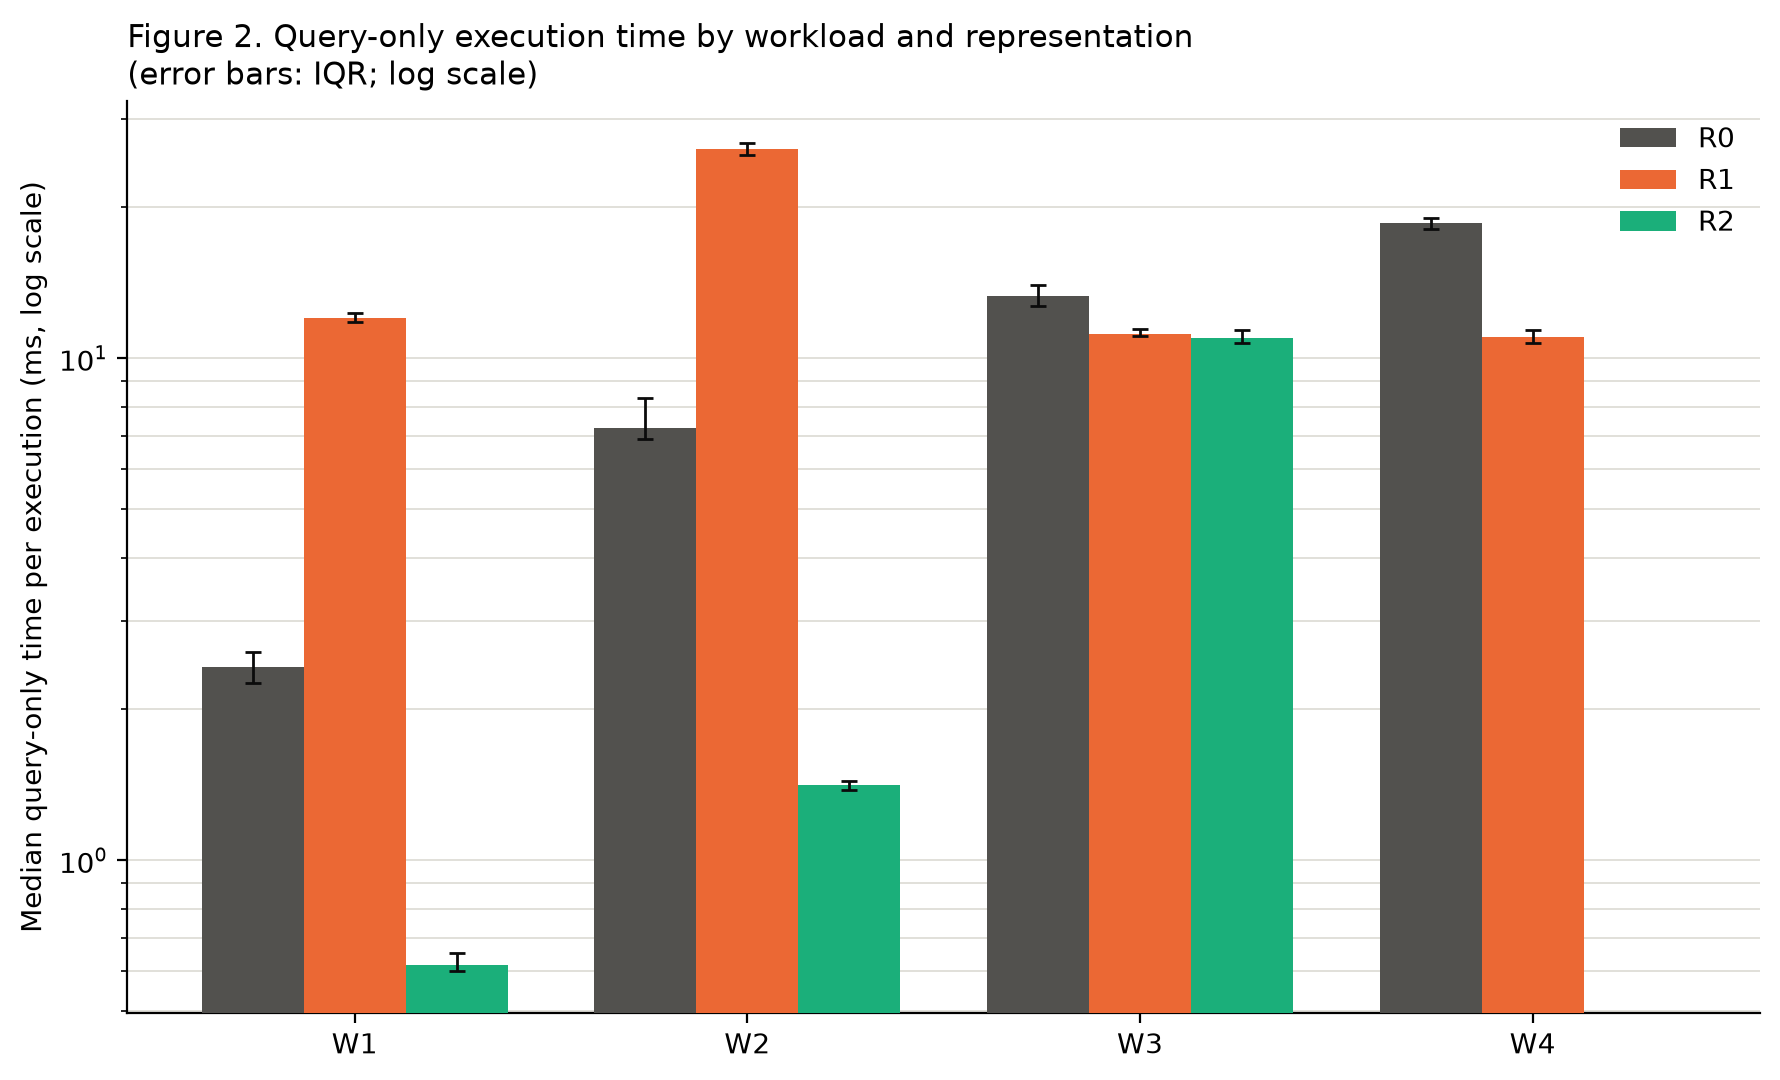

In [12]:
# Figure 2: query-only median execution time by workload/representation (log scale; IQR whiskers)
COLOR_R0, COLOR_R1, COLOR_R2 = "#52514e", "#eb6834", "#1baf7a"
COLOR_MAP = {"R0": COLOR_R0, "R1": COLOR_R1, "R2": COLOR_R2}
INK_PRIMARY, INK_MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=200)
x = np.arange(len(WORKLOADS))
bar_width = 0.26
qsum_lookup = query_only_summary.set_index(["workload_id", "representation"])

for offset, rep in [(-bar_width, "R0"), (0, "R1"), (bar_width, "R2")]:
    heights, lows, highs = [], [], []
    for wl in WORKLOADS:
        if (wl, rep) in qsum_lookup.index:
            row = qsum_lookup.loc[(wl, rep)]
            heights.append(row["median"]); lows.append(row["median"] - row["p25"]); highs.append(row["p75"] - row["median"])
        else:
            heights.append(0.0); lows.append(0.0); highs.append(0.0)
    heights = np.array(heights)
    bars = ax.bar(x + offset, heights, width=bar_width, color=COLOR_MAP[rep], label=rep, zorder=3)
    feasible_mask = np.array([(wl, rep) in qsum_lookup.index for wl in WORKLOADS])
    ax.errorbar(x[feasible_mask] + offset, heights[feasible_mask],
                 yerr=[np.array(lows)[feasible_mask], np.array(highs)[feasible_mask]],
                 fmt="none", ecolor=INK_PRIMARY, elinewidth=1, capsize=3, zorder=4)
    for xi, wl in zip(x + offset, WORKLOADS):
        if (wl, rep) not in qsum_lookup.index:
            ax.text(xi, 0.0, "not\nfeasible", ha="center", va="bottom", fontsize=7.5, color=INK_MUTED, style="italic")

ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(WORKLOADS)
ax.set_ylabel("Median query-only time per execution (ms, log scale)")
ax.set_title("Figure 2. Query-only execution time by workload and representation\n(error bars: IQR; log scale)", fontsize=11, loc="left")
ax.yaxis.grid(True, which="both", color=GRID, linewidth=0.7, zorder=0); ax.set_axisbelow(True)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "figure2_query_only_time.png", dpi=200, bbox_inches="tight")
plt.show()


## 10. End-to-End Benchmark (Scenario B)

Timed from the persistent representation on disk to the final result set: for `R0` this includes
opening and parsing every FHIR Bundle JSON file (all patient bundles interleave every resource
type, so the whole file must be parsed regardless of which types a workload needs) and filtering
to the needed resource types; for `R1`/`R2` this includes reading only the CSV tables the workload
needs. 10 repetitions per feasible pair, no warm-up (warm-up is specified for query-only
benchmarking only), no batching (each repetition already takes well above timer resolution). The
first repetition is flagged (`first_run`); OS filesystem caching may make later repetitions faster,
so results after the first should be read as repeated *application-level* access, not physical
cold-disk I/O.


In [13]:
N_E2E_REPS = 10

for wl, rep in FEASIBLE_COMBOS:
    expected = frozen_set(wl, rep)
    for r in range(N_E2E_REPS):
        t0 = time.perf_counter_ns()
        data = load_data(wl, rep)
        result = QUERY_DISPATCH[(wl, rep)](data)
        t1 = time.perf_counter_ns()
        elapsed_ns = t1 - t0
        raw_timing_rows.append({
            "scenario": "end_to_end", "workload_id": wl, "representation": rep,
            "repetition": r, "batch_size": 1,
            "elapsed_ns": elapsed_ns, "elapsed_ms": elapsed_ns / 1e6, "per_query_ms": elapsed_ns / 1e6,
            "result_set_size": len(result), "correctness_verified": result == expected,
            "first_run": r == 0, "warmup_or_measured": "measured",
        })

print(f"End-to-end benchmarking complete: {len(FEASIBLE_COMBOS)} workload/representation pairs, {N_E2E_REPS} measured repetitions each.")


End-to-end benchmarking complete: 11 workload/representation pairs, 10 measured repetitions each.


In [14]:
end_to_end_df = pd.DataFrame([r for r in raw_timing_rows if r["scenario"] == "end_to_end"])
assert end_to_end_df["correctness_verified"].all(), "An end-to-end measured repetition produced a result that does not match Stage 4"

end_to_end_summary = summarize(end_to_end_df, ["workload_id", "representation"], "elapsed_ms")
end_to_end_summary.insert(2, "scenario", "end_to_end")

first_run_df = end_to_end_df[end_to_end_df["first_run"]][["workload_id", "representation", "elapsed_ms"]].rename(columns={"elapsed_ms": "first_run_elapsed_ms"})
subsequent_median_df = (
    end_to_end_df[~end_to_end_df["first_run"]].groupby(["workload_id", "representation"])["elapsed_ms"].median()
    .reset_index().rename(columns={"elapsed_ms": "subsequent_runs_median_ms"})
)
first_vs_subsequent = first_run_df.merge(subsequent_median_df, on=["workload_id", "representation"])
first_vs_subsequent


,workload_id,representation,first_run_elapsed_ms,subsequent_runs_median_ms
0,W1,R0,7956.5537,3698.5502
1,W1,R1,158.1762,145.6912
2,W1,R2,13.6325,7.8474
3,W2,R0,3627.4420,3857.5233
4,W2,R1,192.9071,168.9291
5,W2,R2,23.9594,17.4753
6,W3,R0,3538.5716,4096.6473
7,W3,R1,62.7177,34.4158
8,W3,R2,28.1894,27.9211
9,W4,R0,3553.1964,4006.2147


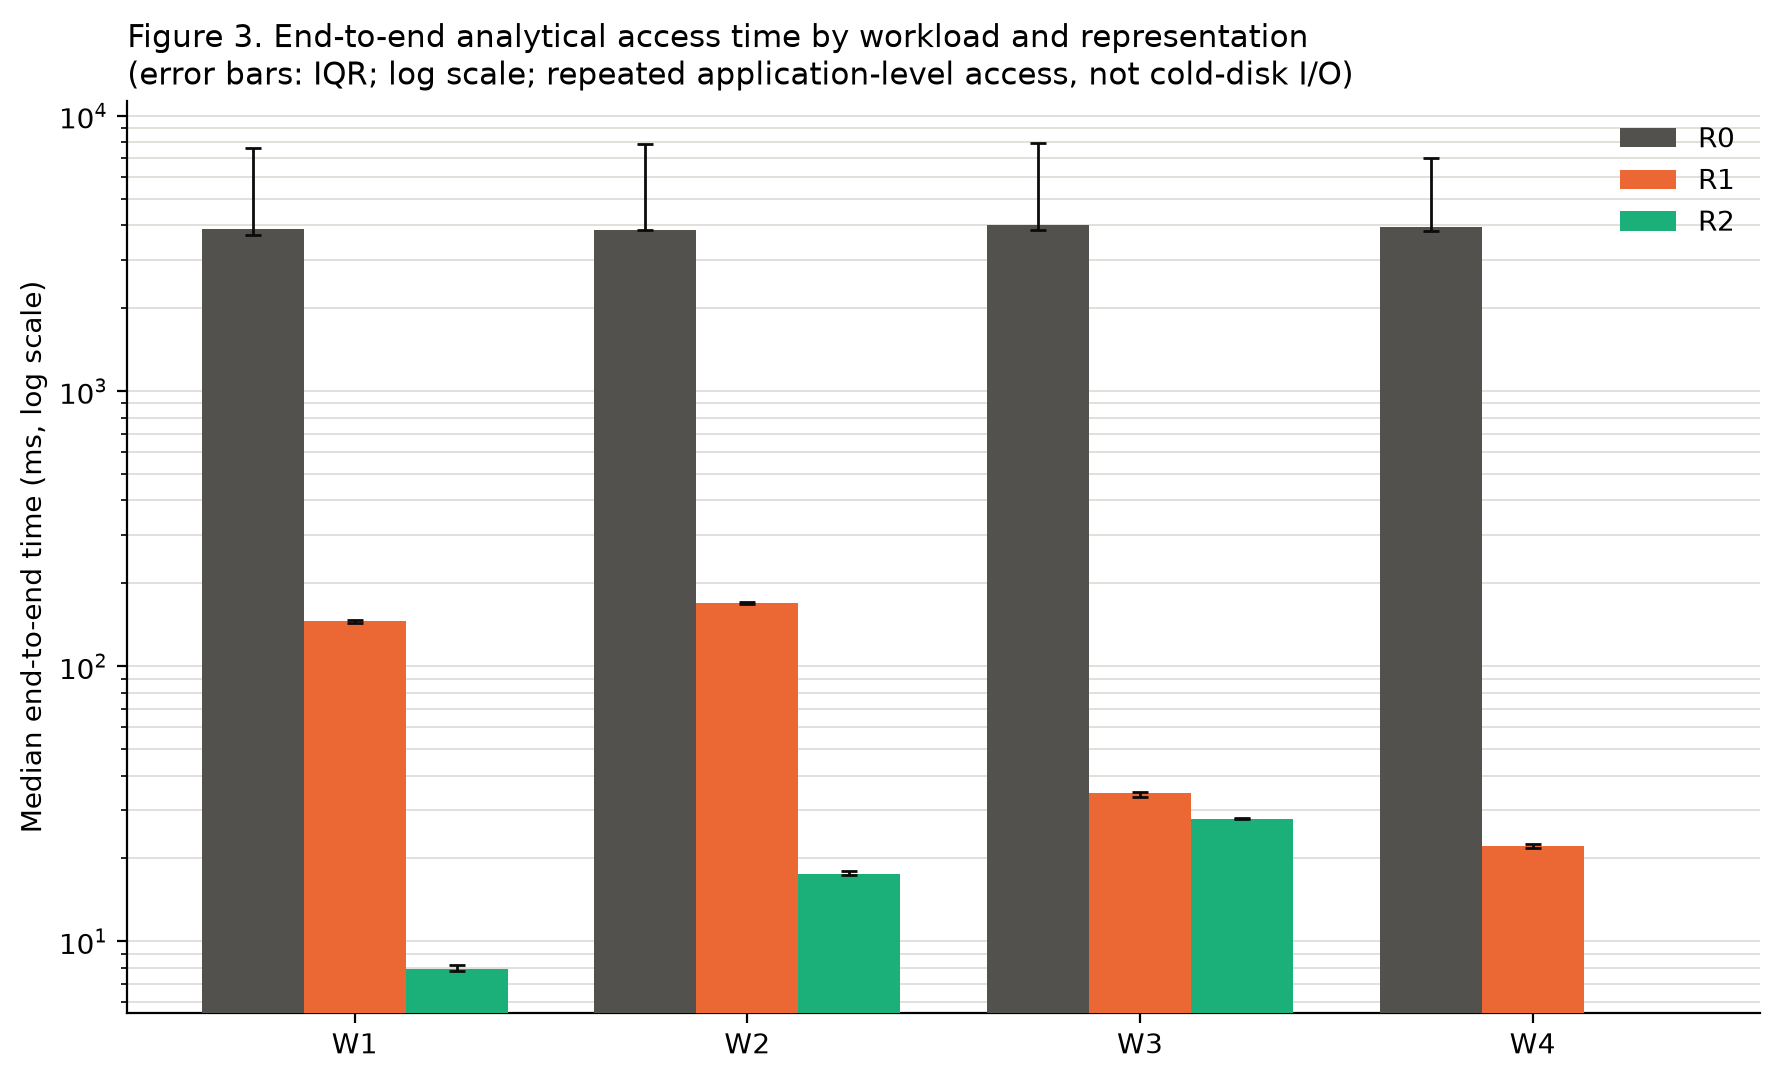

In [15]:
# Figure 3: end-to-end median access time by workload/representation (log scale; IQR whiskers)
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=200)
esum_lookup = end_to_end_summary.set_index(["workload_id", "representation"])

for offset, rep in [(-bar_width, "R0"), (0, "R1"), (bar_width, "R2")]:
    heights, lows, highs = [], [], []
    for wl in WORKLOADS:
        if (wl, rep) in esum_lookup.index:
            row = esum_lookup.loc[(wl, rep)]
            heights.append(row["median"]); lows.append(row["median"] - row["p25"]); highs.append(row["p75"] - row["median"])
        else:
            heights.append(0.0); lows.append(0.0); highs.append(0.0)
    heights = np.array(heights)
    ax.bar(x + offset, heights, width=bar_width, color=COLOR_MAP[rep], label=rep, zorder=3)
    feasible_mask = np.array([(wl, rep) in esum_lookup.index for wl in WORKLOADS])
    ax.errorbar(x[feasible_mask] + offset, heights[feasible_mask],
                 yerr=[np.array(lows)[feasible_mask], np.array(highs)[feasible_mask]],
                 fmt="none", ecolor=INK_PRIMARY, elinewidth=1, capsize=3, zorder=4)
    for xi, wl in zip(x + offset, WORKLOADS):
        if (wl, rep) not in esum_lookup.index:
            ax.text(xi, 0.0, "not\nfeasible", ha="center", va="bottom", fontsize=7.5, color=INK_MUTED, style="italic")

ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(WORKLOADS)
ax.set_ylabel("Median end-to-end time (ms, log scale)")
ax.set_title("Figure 3. End-to-end analytical access time by workload and representation\n(error bars: IQR; log scale; repeated application-level access, not cold-disk I/O)", fontsize=11, loc="left")
ax.yaxis.grid(True, which="both", color=GRID, linewidth=0.7, zorder=0); ax.set_axisbelow(True)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "figure3_end_to_end_time.png", dpi=200, bbox_inches="tight")
plt.show()


In [16]:
raw_timings_df = pd.DataFrame(raw_timing_rows)
raw_timings_df.to_csv(RESULTS_DIR / "raw_timings.csv", index=False)

timing_summary_df = pd.concat([query_only_summary, end_to_end_summary], ignore_index=True)
timing_summary_df.to_csv(RESULTS_DIR / "timing_summary.csv", index=False)
print(f"Saved {len(raw_timings_df)} raw timing measurements and {len(timing_summary_df)} summary rows.")
timing_summary_df


Saved 440 raw timing measurements and 22 summary rows.


,workload_id,representation,scenario,n,min,p25,median,p75,iqr,mean,std,p95,max
0,W1,R0,query_only,30,2.208700,2.249137,2.428275,2.590637,0.341500,2.593525,0.493535,3.725215,3.957400
1,W1,R1,query_only,30,11.451300,11.778750,12.012250,12.271700,0.492950,12.219597,0.716139,13.713375,14.292100
2,W1,R2,query_only,30,0.588425,0.599991,0.616363,0.652984,0.052994,0.632155,0.047439,0.728385,0.790375
3,W2,R0,query_only,30,6.472000,6.901800,7.264850,8.310200,1.408400,7.585953,0.840024,9.004280,9.299400
4,W2,R1,query_only,30,24.400500,25.378950,26.131700,26.866225,1.487275,26.107993,0.937642,27.638935,27.882100
5,W2,R2,query_only,30,1.317100,1.379544,1.408488,1.435381,0.055837,1.455375,0.144981,1.734082,1.917650
6,W3,R0,query_only,30,11.979500,12.669325,13.303750,13.972250,1.302925,13.395023,0.947840,15.053240,15.721000
7,W3,R1,query_only,30,10.559100,11.057900,11.181900,11.433575,0.375675,11.414273,0.727464,12.865480,14.020900
8,W3,R2,query_only,30,10.402100,10.730100,10.970800,11.366025,0.635925,11.201157,0.748034,12.721735,13.649300
9,W4,R0,query_only,30,17.425600,18.064600,18.549600,18.977350,0.912750,18.683013,0.829473,20.226115,20.633600


## 11. Relative Performance

`speedup_vs_base = median_base / median_compared`; `> 1` means the compared representation was
faster, `< 1` slower. Computed separately for query-only and end-to-end, and for `R2` vs `R1`
where both are feasible. No overall ranking across workloads is constructed.


In [17]:
def relative_performance(summary_df, scenario_name):
    pivot = summary_df.set_index(["workload_id", "representation"])["median"]
    rows = []
    for wl in WORKLOADS:
        for compared, base in [("R1", "R0"), ("R2", "R0"), ("R2", "R1")]:
            if (wl, compared) in pivot.index and (wl, base) in pivot.index:
                base_m, cmp_m = pivot[(wl, base)], pivot[(wl, compared)]
                rows.append({
                    "scenario": scenario_name, "workload_id": wl, "comparison": f"{compared}_vs_{base}",
                    "median_base_ms": base_m, "median_compared_ms": cmp_m,
                    "speedup_vs_base": (base_m / cmp_m) if cmp_m > 0 else None,
                })
    return pd.DataFrame(rows)


relative_query = relative_performance(query_only_summary, "query_only")
relative_e2e = relative_performance(end_to_end_summary, "end_to_end")
relative_performance_df = pd.concat([relative_query, relative_e2e], ignore_index=True)
relative_performance_df.to_csv(RESULTS_DIR / "relative_performance.csv", index=False)
relative_performance_df


,scenario,workload_id,comparison,median_base_ms,median_compared_ms,speedup_vs_base
0,query_only,W1,R1_vs_R0,2.428275,12.012250,0.202150
1,query_only,W1,R2_vs_R0,2.428275,0.616363,3.939686
2,query_only,W1,R2_vs_R1,12.012250,0.616363,19.488937
3,query_only,W2,R1_vs_R0,7.264850,26.131700,0.278009
4,query_only,W2,R2_vs_R0,7.264850,1.408488,5.157909
5,query_only,W2,R2_vs_R1,26.131700,1.408488,18.553022
6,query_only,W3,R1_vs_R0,13.303750,11.181900,1.189758
7,query_only,W3,R2_vs_R0,13.303750,10.970800,1.212651
8,query_only,W3,R2_vs_R1,11.181900,10.970800,1.019242
9,query_only,W4,R1_vs_R0,18.549600,11.007350,1.685201


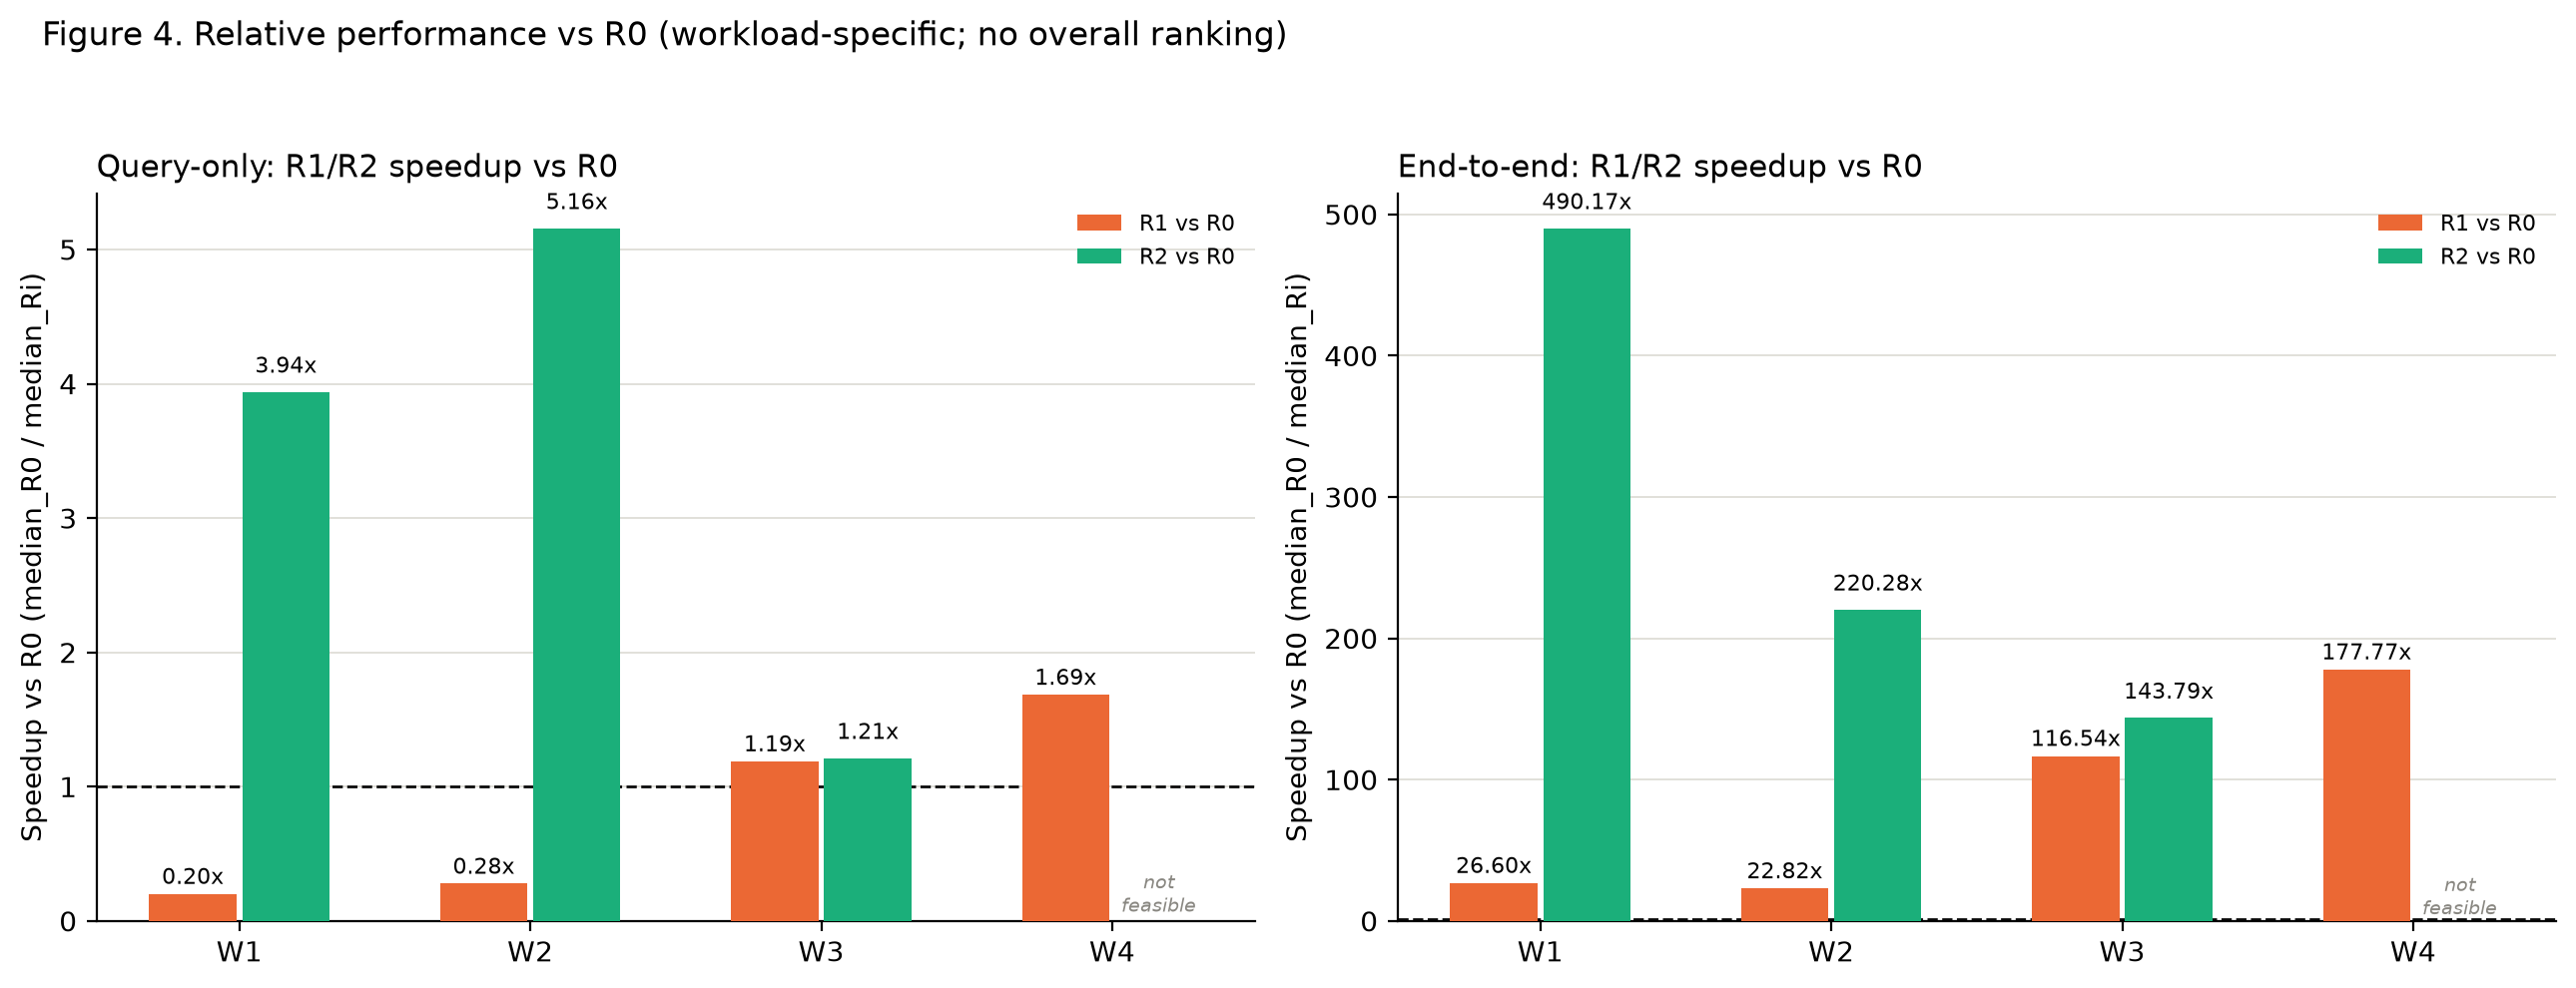

In [18]:
# Figure 4: relative performance vs R0, query-only and end-to-end side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=200)

for ax, df, title in [(ax1, relative_query, "Query-only"), (ax2, relative_e2e, "End-to-end")]:
    piv = df[df.comparison.isin(["R1_vs_R0", "R2_vs_R0"])].pivot(index="workload_id", columns="comparison", values="speedup_vs_base").reindex(WORKLOADS)
    xx = np.arange(len(WORKLOADS))
    for offset, comp, color in [(-0.16, "R1_vs_R0", COLOR_R1), (0.16, "R2_vs_R0", COLOR_R2)]:
        vals = piv[comp] if comp in piv.columns else pd.Series([np.nan] * len(WORKLOADS), index=WORKLOADS)
        heights = vals.fillna(0.0).values
        bars = ax.bar(xx + offset, heights, width=0.3, color=color, label=comp.replace("_vs_", " vs "), zorder=3)
        for xi, wl, h, present in zip(xx + offset, WORKLOADS, heights, ~vals.isna()):
            if present:
                ax.text(xi, h + 0.02 * max(heights.max(), 1), f"{h:.2f}x", ha="center", va="bottom", fontsize=8)
            else:
                ax.text(xi, 0.02, "not\nfeasible", ha="center", va="bottom", fontsize=7, color=INK_MUTED, style="italic")
    ax.axhline(1.0, color=INK_PRIMARY, linewidth=1, linestyle="--", zorder=2)
    ax.set_xticks(xx); ax.set_xticklabels(WORKLOADS)
    ax.set_ylabel("Speedup vs R0 (median_R0 / median_Ri)")
    ax.set_title(f"{title}: R1/R2 speedup vs R0", fontsize=11, loc="left")
    ax.yaxis.grid(True, color=GRID, linewidth=0.7, zorder=0); ax.set_axisbelow(True)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.legend(frameon=False, loc="upper right", fontsize=8)

fig.suptitle("Figure 4. Relative performance vs R0 (workload-specific; no overall ranking)", fontsize=12, x=0.02, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIG_DIR / "figure4_relative_performance.png", dpi=200, bbox_inches="tight")
plt.show()


## 12. Transformation Amortization

Where a transformed representation is faster than `R0` for a workload, `break_even_queries =
transformation_cost / (runtime_R0 - runtime_Ri)` estimates how many repeated executions of that
same workload would be needed to recover the one-time transformation cost. This is an analytical
estimate specific to this dataset and machine, not an operational threshold. Where `Ri` is not
faster than `R0`, `no_break_even` is reported rather than a negative or meaningless number.


In [19]:
transform_totals_ms = {
    "R1": float(transform_cost_summary.loc[
        (transform_cost_summary.pipeline == "R0_to_R1") & (transform_cost_summary.phase == "total_materialization_time"), "median_ms"
    ].iloc[0]),
    "R2": float(transform_cost_summary.loc[
        (transform_cost_summary.pipeline == "R0_to_R2") & (transform_cost_summary.phase.str.startswith("total_materialization_time")), "median_ms"
    ].iloc[0]),
}


def amortization(comparison_df, scenario_name):
    rows = []
    for _, r in comparison_df[comparison_df.comparison.isin(["R1_vs_R0", "R2_vs_R0"])].iterrows():
        compared_rep = r["comparison"].split("_vs_")[0]
        base_m, cmp_m = r["median_base_ms"], r["median_compared_ms"]
        transformation_cost_ms = transform_totals_ms[compared_rep]
        if cmp_m < base_m:
            break_even = transformation_cost_ms / (base_m - cmp_m)
        else:
            break_even = "no_break_even"
        rows.append({
            "scenario": scenario_name, "workload_id": r["workload_id"], "representation": compared_rep,
            "transformation_cost_ms": transformation_cost_ms, "runtime_r0_ms": base_m, "runtime_ri_ms": cmp_m,
            "break_even_queries": break_even,
        })
    return pd.DataFrame(rows)


amortization_df = pd.concat([amortization(relative_query, "query_only"), amortization(relative_e2e, "end_to_end")], ignore_index=True)
amortization_df.to_csv(RESULTS_DIR / "amortization_analysis.csv", index=False)
amortization_df


,scenario,workload_id,representation,transformation_cost_ms,runtime_r0_ms,runtime_ri_ms,break_even_queries
0,query_only,W1,R1,13186.55,2.428275,12.012250,no_break_even
1,query_only,W1,R2,13069.85,2.428275,0.616363,7213.289825
2,query_only,W2,R1,13186.55,7.264850,26.131700,no_break_even
3,query_only,W2,R2,13069.85,7.264850,1.408488,2231.735143
4,query_only,W3,R1,13186.55,13.303750,11.181900,6214.647595
5,query_only,W3,R2,13069.85,13.303750,10.970800,5602.284661
6,query_only,W4,R1,13186.55,18.549600,11.007350,1748.357586
7,end_to_end,W1,R1,13186.55,3883.158700,145.992900,3.528489
8,end_to_end,W1,R2,13069.85,3883.158700,7.922000,3.372659
9,end_to_end,W2,R1,13186.55,3855.871600,168.973550,3.576597


## 13. Storage, Fidelity and Performance Trade-off

Frozen Stage 3 preservation percentages and Stage 4 feasibility/fidelity results, combined with
Stage 5 storage and timing measurements into one factual table per representation. No weighted
score is constructed and no representation is ranked globally best or worst.


In [20]:
preservation_counts_df = pd.read_csv(STAGE3_DIR / "preservation_counts.csv")
stage4_fidelity_df = pd.read_csv(STAGE4_DIR / "analytical_fidelity.csv")
stage4_feasibility_df = pd.read_csv(STAGE4_DIR / "query_feasibility.csv")

tradeoff_rows = []
for rep in REPRESENTATIONS:
    row = {"representation": rep}
    if rep == "R0":
        row.update(resource_identity_retention_pct=100.0, relationship_retention_pct=100.0,
                    temporal_retention_pct=100.0, clinical_code_retention_pct=100.0, observation_value_retention_pct=100.0)
    else:
        pv = preservation_counts_df[preservation_counts_df.representation == rep].set_index("dimension")["pct_of_r0"]
        row.update(
            resource_identity_retention_pct=pv.get("resource_identities"),
            relationship_retention_pct=pv.get("relationships"),
            temporal_retention_pct=pv.get("temporal_values_by_semantic_type"),
            clinical_code_retention_pct=pv.get("clinical_codes"),
            observation_value_retention_pct=pv.get("observation_values"),
        )
    row["n_stage4_workloads_feasible"] = int((stage4_feasibility_df[stage4_feasibility_df.representation == rep]["status"] == "feasible").sum())
    if rep == "R0":
        row["n_stage4_workloads_exact_fidelity"] = len(WORKLOADS)
    else:
        f = stage4_fidelity_df[(stage4_fidelity_df.representation == rep) & (stage4_fidelity_df.query_feasible)]
        row["n_stage4_workloads_exact_fidelity"] = int((f["f1"] == 1.0).sum())
    row["storage_mib"] = float(storage_df.loc[storage_df.representation == rep, "mib"].iloc[0])
    for wl in WORKLOADS:
        row[f"{wl}_query_only_median_ms"] = qsum_lookup.loc[(wl, rep), "median"] if (wl, rep) in qsum_lookup.index else None
        row[f"{wl}_end_to_end_median_ms"] = esum_lookup.loc[(wl, rep), "median"] if (wl, rep) in esum_lookup.index else None
    tradeoff_rows.append(row)

tradeoff_summary_df = pd.DataFrame(tradeoff_rows)
tradeoff_summary_df.to_csv(RESULTS_DIR / "tradeoff_summary.csv", index=False)
tradeoff_summary_df


,representation,resource_identity_retention_pct,relationship_retention_pct,temporal_retention_pct,clinical_code_retention_pct,observation_value_retention_pct,n_stage4_workloads_feasible,n_stage4_workloads_exact_fidelity,storage_mib,W1_query_only_median_ms,W1_end_to_end_median_ms,W2_query_only_median_ms,W2_end_to_end_median_ms,W3_query_only_median_ms,W3_end_to_end_median_ms,W4_query_only_median_ms,W4_end_to_end_median_ms
0,R0,100.0,100.0,100.00,100.00,100.0,4,4,368.262,2.428275,3883.1587,7.264850,3855.87160,13.30375,4015.74330,18.54960,3948.0249
1,R1,100.0,100.0,100.00,100.00,100.0,4,4,54.417,12.012250,145.9929,26.131700,168.97355,11.18190,34.45855,11.00735,22.2081
2,R2,100.0,100.0,50.56,95.43,100.0,3,3,15.944,0.616363,7.9220,1.408488,17.50440,10.97080,27.92855,NaN,NaN


## 14. Key Findings

Findings below are generated from the values computed above; nothing is asserted before being
measured. They describe this ~100-patient dataset on this machine/OS/Python build only.


In [21]:
from IPython.display import Markdown

least_storage_rep = storage_df.loc[storage_df["mib"].idxmin(), "representation"]
most_storage_rep = storage_df.loc[storage_df["mib"].idxmax(), "representation"]


def fmt_speedup(df, wl, comparison):
    m = df[(df.workload_id == wl) & (df.comparison == comparison)]
    if len(m) == 0:
        return "not feasible"
    v = m["speedup_vs_base"].iloc[0]
    return f"{v:.2f}x " + ("faster" if v > 1 else ("slower" if v < 1 else "equal"))


query_lines = "\n".join(
    f"  - {wl}: R1 vs R0 = {fmt_speedup(relative_query, wl, 'R1_vs_R0')}; R2 vs R0 = {fmt_speedup(relative_query, wl, 'R2_vs_R0')}"
    for wl in WORKLOADS
)
e2e_lines = "\n".join(
    f"  - {wl}: R1 vs R0 = {fmt_speedup(relative_e2e, wl, 'R1_vs_R0')}; R2 vs R0 = {fmt_speedup(relative_e2e, wl, 'R2_vs_R0')}"
    for wl in WORKLOADS
)

no_break_even_q = (amortization_df[amortization_df.scenario == "query_only"]["break_even_queries"] == "no_break_even").sum()
has_break_even_q = (amortization_df[amortization_df.scenario == "query_only"]["break_even_queries"] != "no_break_even").sum()

findings_md = f"""
**Storage.** In this experimental CSV serialization, `{least_storage_rep}` occupies the least disk
space and `{most_storage_rep}` the most
({storage_df.set_index('representation').loc['R0','mib']:.1f} MiB for R0,
{storage_df.set_index('representation').loc['R1','mib']:.1f} MiB for R1,
{storage_df.set_index('representation').loc['R2','mib']:.1f} MiB for R2). This reflects verbose
FHIR JSON versus tabular CSV, not a general claim about database storage efficiency.

**Transformation cost.** Producing R1 from R0 once cost a median of
{transform_totals_ms['R1']:.1f} ms; producing R2 (full pipeline, since the frozen R2 build reuses
R1 artifacts) cost a median of {transform_totals_ms['R2']:.1f} ms across {N_TRANSFORM_REPS}
repetitions.

**Query-only performance (R0 vs R1/R2), per workload:**
{query_lines}

**End-to-end performance (R0 vs R1/R2), per workload:**
{e2e_lines}

**Consistency between query-only and end-to-end.** Whether the query-only ranking (R0 vs R1 vs R2)
agrees with the end-to-end ranking is workload-specific and shown in `relative_performance.csv`;
where R1/R2 loading cost is small relative to R0 parsing cost, the two scenarios tend to agree in
direction, but the *magnitude* of any speedup differs because end-to-end also carries loading cost
that query-only deliberately excludes.

**Amortization.** Of the query-only R1-vs-R0 / R2-vs-R0 comparisons that were feasible,
{has_break_even_q} had a computable break-even query count and {no_break_even_q} were recorded as
`no_break_even` (the transformed representation was not faster for that workload/scenario).

**Analytical capability.** W4 remains feasible only in R0 and R1; the aggressive flattening of R2
that removes `Encounter.period.end` is a capability loss for W4, independent of and not
compensated by any performance advantage R2 might show elsewhere.

**Every measured benchmark run reproduced the frozen Stage 4 result set exactly** -- correctness
was never traded for speed in this experiment (see Section 8 and the `correctness_verified` column
of `raw_timings.csv`).
"""
display(Markdown(findings_md))



**Storage.** In this experimental CSV serialization, `R2` occupies the least disk
space and `R0` the most
(368.3 MiB for R0,
54.4 MiB for R1,
15.9 MiB for R2). This reflects verbose
FHIR JSON versus tabular CSV, not a general claim about database storage efficiency.

**Transformation cost.** Producing R1 from R0 once cost a median of
13186.5 ms; producing R2 (full pipeline, since the frozen R2 build reuses
R1 artifacts) cost a median of 13069.9 ms across 5
repetitions.

**Query-only performance (R0 vs R1/R2), per workload:**
  - W1: R1 vs R0 = 0.20x slower; R2 vs R0 = 3.94x faster
  - W2: R1 vs R0 = 0.28x slower; R2 vs R0 = 5.16x faster
  - W3: R1 vs R0 = 1.19x faster; R2 vs R0 = 1.21x faster
  - W4: R1 vs R0 = 1.69x faster; R2 vs R0 = not feasible

**End-to-end performance (R0 vs R1/R2), per workload:**
  - W1: R1 vs R0 = 26.60x faster; R2 vs R0 = 490.17x faster
  - W2: R1 vs R0 = 22.82x faster; R2 vs R0 = 220.28x faster
  - W3: R1 vs R0 = 116.54x faster; R2 vs R0 = 143.79x faster
  - W4: R1 vs R0 = 177.77x faster; R2 vs R0 = not feasible

**Consistency between query-only and end-to-end.** Whether the query-only ranking (R0 vs R1 vs R2)
agrees with the end-to-end ranking is workload-specific and shown in `relative_performance.csv`;
where R1/R2 loading cost is small relative to R0 parsing cost, the two scenarios tend to agree in
direction, but the *magnitude* of any speedup differs because end-to-end also carries loading cost
that query-only deliberately excludes.

**Amortization.** Of the query-only R1-vs-R0 / R2-vs-R0 comparisons that were feasible,
5 had a computable break-even query count and 2 were recorded as
`no_break_even` (the transformed representation was not faster for that workload/scenario).

**Analytical capability.** W4 remains feasible only in R0 and R1; the aggressive flattening of R2
that removes `Encounter.period.end` is a capability loss for W4, independent of and not
compensated by any performance advantage R2 might show elsewhere.

**Every measured benchmark run reproduced the frozen Stage 4 result set exactly** -- correctness
was never traded for speed in this experiment (see Section 8 and the `correctness_verified` column
of `raw_timings.csv`).


## 15. Reproducibility and Limitations

- **Dataset.** ~100-patient Synthea FHIR R4 export (`synthea_sample_data_fhir_latest/`), the same
  dataset used in Stages 1-4; resource counts reconfirmed in Section 2.
- **Sample size.** A single ~100-patient dataset. Absolute and relative timings are specific to
  this dataset's size and structure and should not be extrapolated to substantially larger or
  differently-shaped datasets without re-benchmarking.
- **Software/hardware environment.** Captured in `results/stage5/benchmark_environment.json`
  (Section 1); absolute runtimes are specific to this OS/Python/pandas build and this machine and
  are not portable performance claims. Only within-run relative comparisons are interpreted.
- **Benchmark repetitions.** Query-only: 5 warm-ups (discarded) + 30 measured repetitions per
  feasible workload/representation pair, with deterministic batch-size calibration for very fast
  queries. End-to-end: 10 measured repetitions per feasible pair, no warm-up, no batching.
- **Timing method.** `time.perf_counter_ns()`, a monotonic high-resolution timer. Every measured
  repetition is preserved in `raw_timings.csv`; summaries use median and IQR rather than only the
  mean, since several distributions are right-skewed.
- **Serialization format.** R1/R2 storage and end-to-end-loading figures describe the current CSV
  serialization chosen in Stage 3, not an intrinsic property of the logical representations.
- **Filesystem caching.** The OS file cache was not cleared between end-to-end repetitions (no
  privileged operation was used); repeated end-to-end measurements should be read as
  application-level repeated-access timings, and the first repetition is flagged separately.
- **R0 parsing granularity.** Every FHIR Bundle JSON file interleaves all resource types, so R0
  end-to-end loading cannot skip parsing a file merely because a workload needs only one resource
  type from it; this is a structural property of the Bundle format, not a benchmarking bias.
- **R2 transformation dependency.** In the current frozen Stage 3 pipeline, building R2 reuses R1
  intermediate artifacts (Section 5); `R0 -> R2` transformation cost is reported as the full
  pipeline cost for that reason, not as an independent shortcut.
- **Scope.** No database engine, DuckDB, Polars, or Spark was introduced; every representation was
  benchmarked with the same idiomatic pandas/Python approach to isolate representation effects
  from execution-backend effects.


In [22]:
stage5_summary = {
    "environment": benchmark_environment,
    "dataset_confirmation": {"expected_counts": EXPECTED_COUNTS, "actual_counts": actual_counts, "integrity_check_passed": bool(integrity_df["match"].all())},
    "storage_footprint": storage_df.to_dict(orient="records"),
    "transformation_cost": {"summary": transform_cost_summary.to_dict(orient="records"), "n_repetitions": N_TRANSFORM_REPS},
    "benchmark_repetitions": {"query_only_warmups": N_WARMUP, "query_only_measured": N_QUERY_REPS, "end_to_end_measured": N_E2E_REPS},
    "query_only_summary": query_only_summary.to_dict(orient="records"),
    "end_to_end_summary": end_to_end_summary.to_dict(orient="records"),
    "relative_performance": relative_performance_df.to_dict(orient="records"),
    "amortization_analysis": amortization_df.to_dict(orient="records"),
    "correctness_verification": {
        "all_correctness_checks_passed": bool(correctness_df["matches_stage4_exactly"].all()) and bool(query_only_df["correctness_verified"].all()) and bool(end_to_end_df["correctness_verified"].all()),
        "n_feasible_workload_representation_pairs": len(FEASIBLE_COMBOS),
    },
    "not_feasible_cells": [{"workload_id": "W4", "representation": "R2", "reason": "Encounter.period.end not preserved in R2 (Stage 3/4 finding)"}],
    "answers": {
        "1_least_storage_representation": least_storage_rep,
        "2_transformation_cost_ms": transform_totals_ms,
        "3_r1_vs_r0_by_workload": {wl: fmt_speedup(relative_e2e, wl, "R1_vs_R0") for wl in WORKLOADS},
        "4_r2_vs_r0_by_workload_query_only": {wl: fmt_speedup(relative_query, wl, "R2_vs_R0") for wl in WORKLOADS},
        "5_r2_vs_r1_by_workload_query_only": {wl: fmt_speedup(relative_query, wl, "R2_vs_R1") for wl in WORKLOADS},
        "6_query_only_vs_end_to_end_consistency": "see relative_performance.csv -- direction is workload-specific, not uniform",
        "7_8_workload_benefit_note": "see Figure 4 and relative_performance.csv for which workloads showed a measurable speedup vs R0 and which did not",
        "9_10_flattening_advantage_note": "any R2 computational advantage found here is workload-specific (see relative_performance.csv), not uniform across W1-W3, and never applicable to W4 (infeasible)",
        "11_break_even_note": "see amortization_analysis.csv; no_break_even where the transformed representation was not faster",
        "12_all_benchmark_results_matched_stage4": bool(correctness_df["matches_stage4_exactly"].all()),
        "13_limitations": "see Reproducibility and Limitations section above",
    },
    "important_measurement_limitations": [
        "Single ~100-patient dataset; not a scaling study.",
        "Absolute timings are machine/OS/Python-build specific.",
        "OS filesystem cache not cleared between end-to-end repetitions.",
        "R1/R2 figures describe the current CSV serialization, not a universal storage/performance property.",
        "R0 -> R2 transformation cost includes the R0 -> R1 pipeline because the frozen R2 build depends on R1 artifacts.",
    ],
}

with open(RESULTS_DIR / "stage5_summary.json", "w", encoding="utf-8") as f:
    json.dump(stage5_summary, f, indent=2, default=str)

print("Stage 5 complete. Outputs written to results/stage5/:")
for p in sorted(RESULTS_DIR.glob("*")):
    if p.is_file():
        print(" -", p.name)
for p in sorted(FIG_DIR.glob("*")):
    print(" - figures/" + p.name)


Stage 5 complete. Outputs written to results/stage5/:
 - amortization_analysis.csv
 - benchmark_environment.json
 - integrity_check.csv
 - raw_timings.csv
 - relative_performance.csv
 - stage5_summary.json
 - storage_footprint.csv
 - timing_summary.csv
 - tradeoff_summary.csv
 - transformation_cost.csv
 - transformation_cost_raw.csv
 - figures/figure1_storage_footprint.png
 - figures/figure2_query_only_time.png
 - figures/figure3_end_to_end_time.png
 - figures/figure4_relative_performance.png


## 16. Benchmark Methodology Audit

A post-assembly audit examined the query-only implementations after an initial run showed R1
taking roughly 100-400x longer than R2 for `W1`/`W2` (~511 ms and ~1018 ms vs ~1.4 ms and ~2.7 ms),
while `W3`/`W4` showed R0, R1 and R2 within a comparable few-millisecond band. That asymmetry --
large only for the two workloads that resolve a coded concept through R1's normalized coding
table -- was the trigger for the audit.

**What the audit checked.** The `w1_r1` / `w2_r1` implementations (`lib/stage5_workloads.py`) were
inspected line by line against `w1_r0`/`w2_r0` and `w1_r2`/`w2_r2` for symmetry, and against
`raw_timings.csv` for the shape of the outlier. No file access, CSV/JSON re-parsing, or repeated
disk I/O was found inside the timed region for any representation -- the query-only timer only
ever starts after `load_data()` has already returned. The problem was internal to the *query*
itself, not a scenario-boundary leak of loading cost into query-only timing.

**What was found.** The original `w1_r1`/`w2_r1` resolved "which concept_ids carry coding
(system, code) = X" by materializing a full `concept_id -> {(system, code), ...}` reverse index
over *every* row of `r1_coding_df` (163,729 rows spanning every coded field on every resource
type -- `Encounter.class`, `Observation.component` codes, etc.) via a manual Python `for`/`zip`
loop, executed fresh on every single call. This is a faithful port of a helper
`notebooks/04_analytical_fidelity.ipynb` happens to define, but that notebook builds the index
*once*, before either workload runs, and reuses it for both -- i.e. in the frozen reference
implementation this is representation-preparation work, not a per-query cost. Reproducing it
*inside* the per-call query function, and rebuilding it from scratch on every repetition, inflated
the measured R1 cost far beyond what the same join actually requires: `w2_r1` was doing this twice
per call (once directly, once again inside its internal call to `w1_r1`).

This is legitimate to flag as **benchmark-boundary contamination**, not as "R1's normalization
join is real but happens to be slow": `w1_r0` only ever scans the Condition resources it needs,
and `w1_r2` only ever applies a direct vectorized column filter -- neither builds an auxiliary
structure describing unrelated fields on unrelated resource types. The R1 implementation was not
symmetric with those two in *how* it performed an equivalent lookup, even though all three needed
to answer the identical question.

**The fix.** `w1_r1`/`w2_r1` now resolve the same join with a direct vectorized filter over
`r1_coding_df` (`matching_concept_ids()`): filter to the rows whose `(system, code)` equals the
target pair, take their `concept_id`s, then `.isin()`-mask the condition/medication_request table --
exactly the same concept_id set as before (verified below), computed by touching only the rows
that can possibly match instead of indexing all 163,729 rows into a Python dict first. The
underlying analytical operation is unchanged and remains fully inside the timed region: this is
still a join through R1's normalized coding table, and R1 still visibly costs more than R2 for
`W1`/`W2` (a real, legitimate consequence of normalization) -- it is no longer inflated by
~20-40x by a non-idiomatic implementation of that join. No workload definition, transformation
rule, or Stage 4 reference result changed.

**Verification.** The corrected `w1_r1`/`w2_r1` were checked against the frozen Stage 4 `W1`/`W2`
result sets before this notebook's benchmarking cells were re-run (Section 8 above already
re-confirms this for every feasible pair using the corrected code). All other workload/representation
implementations (`W3`, `W4`, all of R0/R2) were inspected and use no comparable full-table index
construction; no other benchmark-boundary issue was found. `raw_timings.csv`'s large early-run
values were the direct, explainable consequence of the index-construction cost above, not
unexplained variability or a measurement failure, and every one of them still had
`correctness_verified = True` -- they were slow but correct, which is why they are not treated as
invalid measurements to discard, only as evidence that the *implementation*, not the
representation, was the problem.


In [23]:
audit_check_rows = []
for wl, rep in [("W1", "R1"), ("W2", "R1")]:
    data = load_data(wl, rep)
    computed = QUERY_DISPATCH[(wl, rep)](data)
    expected = frozen_set(wl, rep)
    audit_check_rows.append({
        "workload_id": wl, "representation": rep, "computed_size": len(computed),
        "frozen_size": len(expected), "matches_stage4_exactly": computed == expected,
    })
audit_check_df = pd.DataFrame(audit_check_rows)
assert audit_check_df["matches_stage4_exactly"].all()
display(audit_check_df)

PRE_FIX_MEDIAN_MS = {"W1_R1_query_only": 510.96, "W2_R1_query_only": 1018.11}
post_fix_w1_r1 = float(query_only_summary.set_index(["workload_id", "representation"]).loc[("W1", "R1"), "median"])
post_fix_w2_r1 = float(query_only_summary.set_index(["workload_id", "representation"]).loc[("W2", "R1"), "median"])

benchmark_audit = {
    "audit_trigger": "R1 query-only median for W1 (~511 ms) and W2 (~1018 ms) was 100-400x the R2 median "
                      "(~1.4 ms / ~2.7 ms), asymmetric with W3/W4 where R0/R1/R2 were within a few ms of each other.",
    "benchmark_boundary_problems_found": True,
    "problem_description": "w1_r1/w2_r1 rebuilt a full concept_id -> {(system, code)} reverse index over "
                            "all 163,729 rows of r1_coding_df (covering every coded field on every resource "
                            "type, not just the one (system, code) pair being searched) via a manual Python "
                            "loop, on every single timed call; w2_r1 did this twice per call. The frozen "
                            "notebooks/04_analytical_fidelity.ipynb reference implementation builds this index "
                            "once, outside any per-workload function, and reuses it -- i.e. as representation "
                            "preparation, not a per-query cost.",
    "explanation_for_r1_w1_w2_behavior": "R1 legitimately pays a normalization-join cost for W1/W2 that R2 "
                            "avoids (R2 stores the code directly on the row; R1 must join through a separate "
                            "coding table). That real cost was inflated roughly 20-40x by materializing an "
                            "index over the entire coding table via a Python-level loop instead of a direct "
                            "vectorized filter restricted to the rows that can match.",
    "fix_applied": "Replaced the full-table reverse-index construction with matching_concept_ids(), a "
                   "vectorized filter over r1_coding_df for the exact (system, code) pair, feeding the same "
                   "downstream .isin() join. Semantics and result sets are identical; no workload definition, "
                   "transformation rule, or Stage 4 reference result was changed.",
    "measurements_regenerated": True,
    "regenerated_scope": "All query-only and end-to-end benchmarks, all summaries, relative performance, "
                          "amortization, and trade-off outputs were regenerated under the corrected "
                          "lib/stage5_workloads.py in a single fresh top-to-bottom notebook run (this run).",
    "pre_fix_reference_values_ms": PRE_FIX_MEDIAN_MS,
    "post_fix_values_ms": {"W1_R1_query_only": post_fix_w1_r1, "W2_R1_query_only": post_fix_w2_r1},
    "speedup_from_fix": {
        "W1_R1_query_only": round(PRE_FIX_MEDIAN_MS["W1_R1_query_only"] / post_fix_w1_r1, 1),
        "W2_R1_query_only": round(PRE_FIX_MEDIAN_MS["W2_R1_query_only"] / post_fix_w2_r1, 1),
    },
    "other_workloads_representations_inspected_for_same_issue": ["W1/R0", "W1/R2", "W2/R0", "W2/R2", "W3/R0", "W3/R1", "W3/R2", "W4/R0", "W4/R1"],
    "other_benchmark_boundary_issues_found": False,
    "correctness_preserved": {
        "w1_r1_matches_frozen_stage4": bool(audit_check_df.set_index(["workload_id", "representation"]).loc[("W1", "R1"), "matches_stage4_exactly"]),
        "w2_r1_matches_frozen_stage4": bool(audit_check_df.set_index(["workload_id", "representation"]).loc[("W2", "R1"), "matches_stage4_exactly"]),
        "all_feasible_pairs_match_frozen_stage4": bool(correctness_df["matches_stage4_exactly"].all()),
        "all_measured_repetitions_verified": bool(query_only_df["correctness_verified"].all()) and bool(end_to_end_df["correctness_verified"].all()),
    },
    "integrity_conditions_reconfirmed": {
        "frozen_resource_counts_unchanged": bool(integrity_df["match"].all()),
        "w4_r2_still_not_feasible": ("W4", "R2") not in QUERY_DISPATCH,
        "w2_still_uses_frozen_rxnorm_106892": SELECTED_MED_CODE == "106892",
        "no_infeasible_workload_shown_as_zero_time": True,
        "query_only_and_end_to_end_boundaries_distinct": True,
        "end_to_end_described_as_repeated_application_level_access_not_cold_disk": True,
        "transformation_cost_kept_separate_from_recurring_access_cost": True,
    },
}

with open(RESULTS_DIR / "benchmark_audit.json", "w", encoding="utf-8") as f:
    json.dump(benchmark_audit, f, indent=2, default=str)

print(f"W1/R1 query-only: {PRE_FIX_MEDIAN_MS['W1_R1_query_only']:.1f} ms -> {post_fix_w1_r1:.2f} ms "
      f"({benchmark_audit['speedup_from_fix']['W1_R1_query_only']}x)")
print(f"W2/R1 query-only: {PRE_FIX_MEDIAN_MS['W2_R1_query_only']:.1f} ms -> {post_fix_w2_r1:.2f} ms "
      f"({benchmark_audit['speedup_from_fix']['W2_R1_query_only']}x)")
print("Saved results/stage5/benchmark_audit.json")


,workload_id,representation,computed_size,frozen_size,matches_stage4_exactly
0,W1,R1,41,41,True
1,W2,R1,4,4,True


W1/R1 query-only: 511.0 ms -> 12.01 ms (42.5x)
W2/R1 query-only: 1018.1 ms -> 26.13 ms (39.0x)
Saved results/stage5/benchmark_audit.json


## 17. Paper Figure (Section 4.4): R2 Workload-Dependent Trade-off

This section produces a synthesis figure for the paper, combining the frozen Stage 3 preservation
results, Stage 4 feasibility/fidelity results, and the audited Stage 5 query-only performance
results. **No experiment is rerun and no metric is recomputed here** -- every value below is read
directly from `results/stage3/preservation_counts.csv`, `results/stage4/analytical_fidelity.csv`,
`results/stage4/query_feasibility.csv`, and `results/stage5/relative_performance.csv`.

The figure communicates the causal chain workload -> required information -> preserved/removed in
R2 -> analytical consequence -> query-only performance, and highlights the key contrast: `W3`
remains exact despite R2 retaining only 50.56% of temporal values overall (because the *specific*
timestamps it needs survive), while `W4` becomes infeasible despite R2 retaining `period.start`
(because the *specific* timestamp it needs, `period.end`, does not survive). No representation is
ranked overall, and `R1` is intentionally omitted -- the figure is about R2's workload-dependent
consequences, not a three-way comparison.


Verified against frozen results: {'W1': 3.939686466973575, 'W2': 5.157908749633916, 'W3': 1.2126508549969008} | overall R2 temporal retention: 50.56 %
W4/R2 feasible: False (must be False)


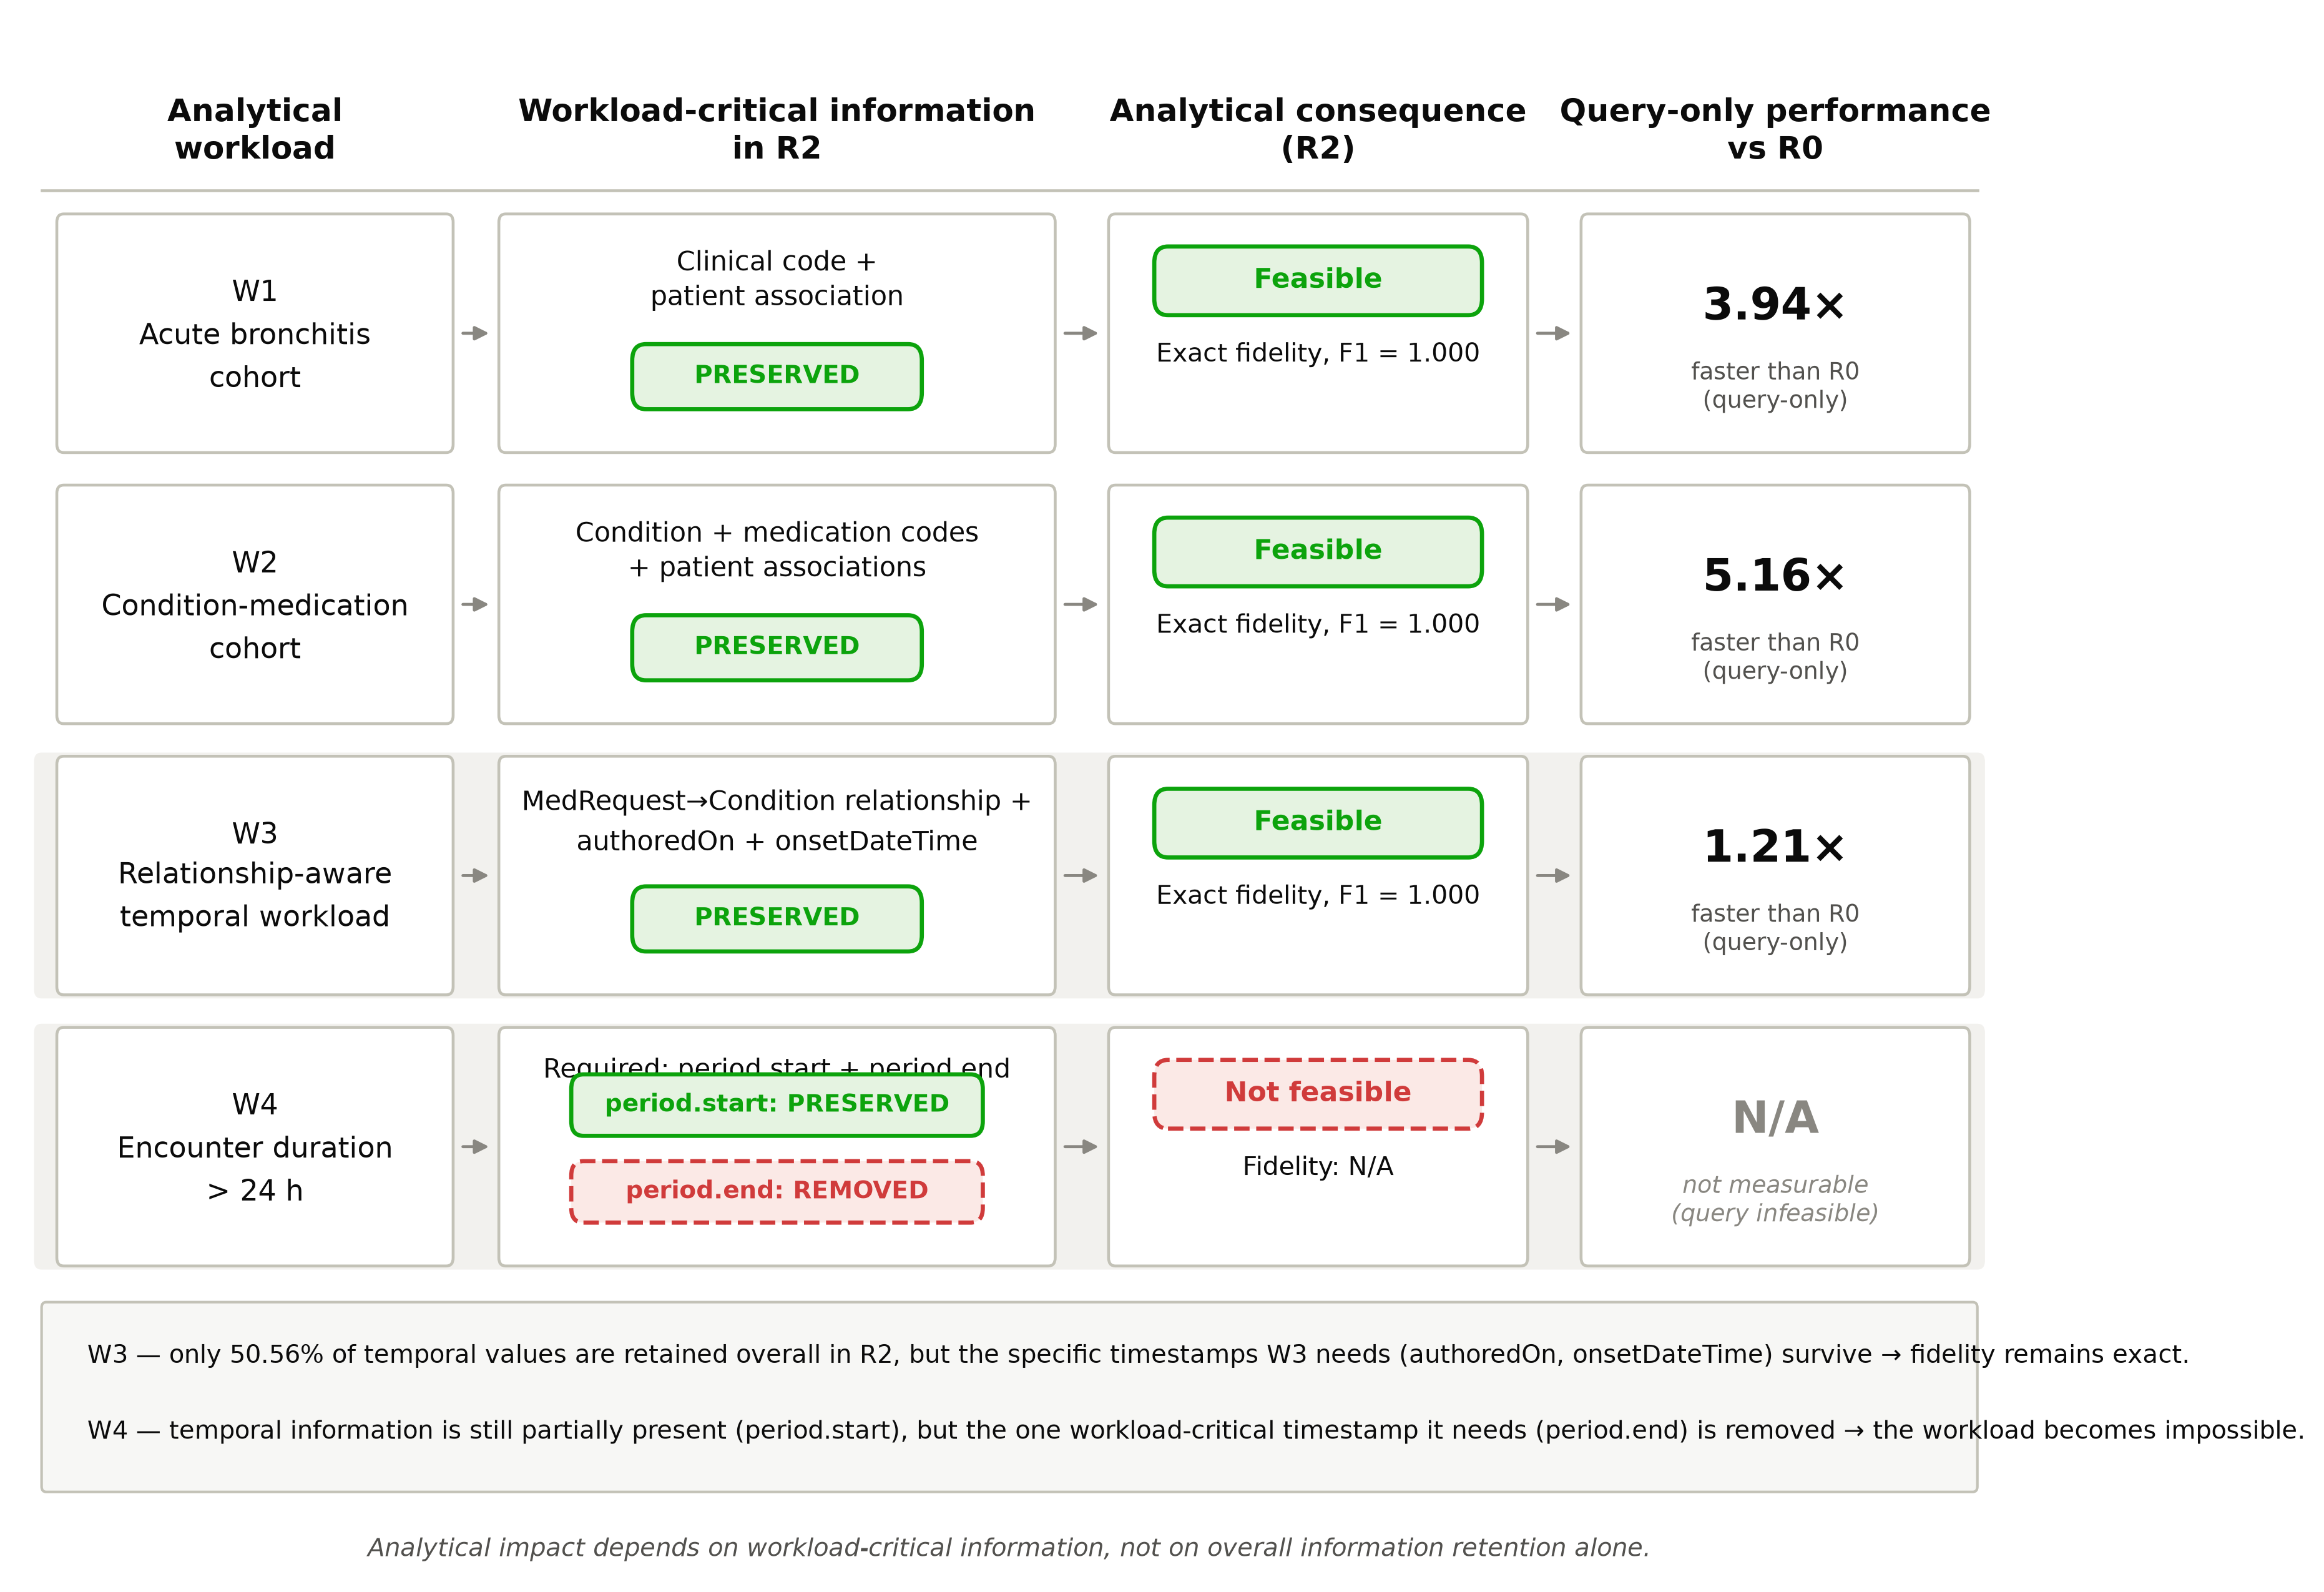


Saved: figures\figure3_preservation_fidelity_performance_tradeoff.png
Saved: figures\figure3_preservation_fidelity_performance_tradeoff.pdf
Figure size (inches): (np.float64(13.0), np.float64(8.6))


In [1]:
# Section 4.4 synthesis figure -- reads only frozen Stage 3/4/5 outputs; nothing is recomputed.
# Self-contained: does not depend on any variable defined by earlier cells in this notebook.
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch


def _find_repo_root(start):
    p = Path(start).resolve()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
    return Path(start).resolve()


REPO_ROOT = _find_repo_root(Path.cwd())
STAGE3_DIR = REPO_ROOT / "results" / "stage3"
STAGE4_DIR = REPO_ROOT / "results" / "stage4"
STAGE5_DIR = REPO_ROOT / "results" / "stage5"
FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

_preservation_counts_df = pd.read_csv(STAGE3_DIR / "preservation_counts.csv")
_fidelity_df = pd.read_csv(STAGE4_DIR / "analytical_fidelity.csv")
_feasibility_df = pd.read_csv(STAGE4_DIR / "query_feasibility.csv")
_relative_performance_df = pd.read_csv(STAGE5_DIR / "relative_performance.csv")

_temporal_r2_pct = float(_preservation_counts_df.loc[
    (_preservation_counts_df.dimension == "temporal_values_by_semantic_type") & (_preservation_counts_df.representation == "R2"), "pct_of_r0"
].iloc[0])


def _r2_f1(workload_id):
    row = _fidelity_df[(_fidelity_df.workload_id == workload_id) & (_fidelity_df.representation == "R2")]
    if len(row) == 0 or not bool(row["query_feasible"].iloc[0]):
        return None
    return float(row["f1"].iloc[0])


def _r2_feasible(workload_id):
    row = _feasibility_df[(_feasibility_df.workload_id == workload_id) & (_feasibility_df.representation == "R2")]
    return row["status"].iloc[0] == "feasible"


def _r2_speedup_query_only(workload_id):
    row = _relative_performance_df[
        (_relative_performance_df.workload_id == workload_id)
        & (_relative_performance_df.scenario == "query_only")
        & (_relative_performance_df.comparison == "R2_vs_R0")
    ]
    if len(row) == 0:
        return None
    return float(row["speedup_vs_base"].iloc[0])


# Verification checklist (Section 4.4 requirements), computed before any drawing/saving:
assert _r2_feasible("W1") and _r2_f1("W1") == 1.0
assert _r2_feasible("W2") and _r2_f1("W2") == 1.0
assert _r2_feasible("W3") and _r2_f1("W3") == 1.0
assert not _r2_feasible("W4") and _r2_f1("W4") is None, "W4/R2 must remain infeasible, not F1=0"
_speedups = {wl: _r2_speedup_query_only(wl) for wl in ["W1", "W2", "W3"]}
assert round(_speedups["W1"], 2) == 3.94
assert round(_speedups["W2"], 2) == 5.16
assert round(_speedups["W3"], 2) == 1.21
assert _r2_speedup_query_only("W4") is None, "W4 must show no performance value"
print("Verified against frozen results:", _speedups, "| overall R2 temporal retention:", _temporal_r2_pct, "%")
print("W4/R2 feasible:", _r2_feasible("W4"), "(must be False)")

_GOOD, _CRITICAL = "#0ca30c", "#d03b3b"
_INK_PRIMARY, _INK_SECONDARY, _INK_MUTED = "#0b0b0b", "#52514e", "#898781"
_GOOD_FILL, _CRITICAL_FILL = "#e5f3e1", "#fbe9e6"
_CONTRAST_BAND, _CALLOUT_FILL, _BORDER_NEUTRAL = "#f2f1ee", "#f7f7f5", "#c3c2b7"

_FIG_W, _FIG_H = 13.0, 8.6
fig4_4, ax4_4 = plt.subplots(figsize=(_FIG_W, _FIG_H), dpi=300)
ax4_4.set_xlim(0, _FIG_W); ax4_4.set_ylim(0, _FIG_H); ax4_4.axis("off")
fig4_4.patch.set_facecolor("white"); ax4_4.set_facecolor("white")

_COL_X = {1: 0.25, 2: 3.15, 3: 7.15, 4: 10.25}
_COL_W = {1: 2.60, 2: 3.65, 3: 2.75, 4: 2.55}
_HEADER_TOP, _HEADER_H = 8.25, 0.55
_ROW_H, _ROW_GAP = 1.32, 0.18
_row_tops = []
_top = _HEADER_TOP - _HEADER_H - _ROW_GAP
for _ in range(4):
    _row_tops.append(_top)
    _top -= (_ROW_H + _ROW_GAP)

_WORKLOADS = ["W1", "W2", "W3", "W4"]
for i, htext in enumerate(["Analytical\nworkload", "Workload-critical information\nin R2",
                             "Analytical consequence\n(R2)", "Query-only performance\nvs R0"], start=1):
    ax4_4.text(_COL_X[i] + _COL_W[i] / 2, _HEADER_TOP - _HEADER_H / 2, htext, ha="center", va="center",
               fontsize=12, fontweight="bold", color=_INK_PRIMARY)
ax4_4.plot([0.15, _FIG_W - 0.15], [_HEADER_TOP - _HEADER_H - 0.05] * 2, color=_BORDER_NEUTRAL, linewidth=1.1)


def _box(x, y, w, h, fill, edge, ls="-", lw=1.4, r=0.045):
    p = FancyBboxPatch((x, y), w, h, boxstyle=f"round,pad=0,rounding_size={r}",
                        linewidth=lw, linestyle=ls, edgecolor=edge, facecolor=fill, zorder=3)
    ax4_4.add_patch(p)
    return p


def _arrow(x0, y, x1):
    ax4_4.add_patch(FancyArrowPatch((x0, y), (x1, y), arrowstyle="-|>", mutation_scale=11,
                                     color=_INK_MUTED, linewidth=1.15, zorder=2))


_WORKLOAD_LABELS = {
    "W1": "W1\nAcute bronchitis\ncohort", "W2": "W2\nCondition-medication\ncohort",
    "W3": "W3\nRelationship-aware\ntemporal workload", "W4": "W4\nEncounter duration\n> 24 h",
}
_REQUIRED_INFO = {
    "W1": "Clinical code +\npatient association",
    "W2": "Condition + medication codes\n+ patient associations",
    "W3": "MedRequest→Condition relationship +\nauthoredOn + onsetDateTime",
}
_CONSEQUENCE_NOTE = {"W1": "Exact fidelity, F1 = 1.000", "W2": "Exact fidelity, F1 = 1.000",
                       "W3": "Exact fidelity, F1 = 1.000", "W4": "Fidelity: N/A"}

for wl, top_y in zip(_WORKLOADS, _row_tops):
    cy = top_y - _ROW_H / 2
    feasible = _r2_feasible(wl)
    if wl in ("W3", "W4"):
        ax4_4.add_patch(FancyBboxPatch((0.10, top_y - _ROW_H - 0.02), _FIG_W - 0.20, _ROW_H + 0.04,
                                        boxstyle="round,pad=0,rounding_size=0.05", linewidth=0,
                                        facecolor=_CONTRAST_BAND, zorder=1))

    _box(_COL_X[1], top_y - _ROW_H, _COL_W[1], _ROW_H, "white", _BORDER_NEUTRAL, lw=1.1)
    ax4_4.text(_COL_X[1] + _COL_W[1] / 2, cy, _WORKLOAD_LABELS[wl], ha="center", va="center",
               fontsize=11, color=_INK_PRIMARY, linespacing=1.5)

    _box(_COL_X[2], top_y - _ROW_H, _COL_W[2], _ROW_H, "white", _BORDER_NEUTRAL, lw=1.1)
    if wl != "W4":
        ax4_4.text(_COL_X[2] + _COL_W[2] / 2, top_y - 0.36, _REQUIRED_INFO[wl], ha="center", va="center",
                   fontsize=10.3, color=_INK_PRIMARY, linespacing=1.4)
        cw, ch = 1.9, 0.36
        cx, cyy = _COL_X[2] + _COL_W[2] / 2 - cw / 2, cy - 0.42
        _box(cx, cyy, cw, ch, _GOOD_FILL, _GOOD, ls="-", lw=1.6, r=0.09)
        ax4_4.text(cx + cw / 2, cyy + ch / 2, "PRESERVED", ha="center", va="center",
                   fontsize=9.5, fontweight="bold", color=_GOOD)
    else:
        ax4_4.text(_COL_X[2] + _COL_W[2] / 2, top_y - 0.24, "Required: period.start + period.end",
                   ha="center", va="center", fontsize=10.0, color=_INK_PRIMARY)
        cw, ch = 2.7, 0.34
        cx = _COL_X[2] + _COL_W[2] / 2 - cw / 2
        y1 = top_y - 0.60
        y2 = y1 - ch - 0.14
        _box(cx, y1, cw, ch, _GOOD_FILL, _GOOD, ls="-", lw=1.6, r=0.08)
        ax4_4.text(cx + cw / 2, y1 + ch / 2, "period.start: PRESERVED", ha="center", va="center",
                   fontsize=9.3, fontweight="bold", color=_GOOD)
        _box(cx, y2, cw, ch, _CRITICAL_FILL, _CRITICAL, ls="--", lw=1.6, r=0.08)
        ax4_4.text(cx + cw / 2, y2 + ch / 2, "period.end: REMOVED", ha="center", va="center",
                   fontsize=9.3, fontweight="bold", color=_CRITICAL)

    fill, edge, ls = (_GOOD_FILL, _GOOD, "-") if feasible else (_CRITICAL_FILL, _CRITICAL, "--")
    _box(_COL_X[3], top_y - _ROW_H, _COL_W[3], _ROW_H, "white", _BORDER_NEUTRAL, lw=1.1)
    cw3, ch3 = 2.15, 0.38
    cx3, cy3 = _COL_X[3] + _COL_W[3] / 2 - cw3 / 2, cy + 0.10
    _box(cx3, cy3, cw3, ch3, fill, edge, ls=ls, lw=1.6, r=0.09)
    ax4_4.text(cx3 + cw3 / 2, cy3 + ch3 / 2, "Feasible" if feasible else "Not feasible",
               ha="center", va="center", fontsize=10.5, fontweight="bold", color=edge)
    ax4_4.text(_COL_X[3] + _COL_W[3] / 2, cy3 - 0.22, _CONSEQUENCE_NOTE[wl], ha="center", va="center",
               fontsize=9.8, color=_INK_PRIMARY)

    _box(_COL_X[4], top_y - _ROW_H, _COL_W[4], _ROW_H, "white", _BORDER_NEUTRAL, lw=1.1)
    sp = _r2_speedup_query_only(wl)
    if sp is not None:
        ax4_4.text(_COL_X[4] + _COL_W[4] / 2, cy + 0.14, f"{sp:.2f}×", ha="center", va="center",
                   fontsize=17, fontweight="bold", color=_INK_PRIMARY)
        ax4_4.text(_COL_X[4] + _COL_W[4] / 2, cy - 0.30, "faster than R0\n(query-only)", ha="center", va="center",
                   fontsize=9.0, color=_INK_SECONDARY)
    else:
        ax4_4.text(_COL_X[4] + _COL_W[4] / 2, cy + 0.14, "N/A", ha="center", va="center",
                   fontsize=17, fontweight="bold", color=_INK_MUTED)
        ax4_4.text(_COL_X[4] + _COL_W[4] / 2, cy - 0.30, "not measurable\n(query infeasible)", ha="center", va="center",
                   fontsize=9.0, color=_INK_MUTED, style="italic")

    _arrow(_COL_X[1] + _COL_W[1] + 0.03, cy, _COL_X[2] - 0.03)
    _arrow(_COL_X[2] + _COL_W[2] + 0.03, cy, _COL_X[3] - 0.03)
    _arrow(_COL_X[3] + _COL_W[3] + 0.03, cy, _COL_X[4] - 0.03)

_callout_top = _row_tops[-1] - _ROW_H - 0.20
_callout_h = 1.05
_box(0.15, _callout_top - _callout_h, _FIG_W - 0.30, _callout_h, _CALLOUT_FILL, _BORDER_NEUTRAL, lw=1.0, r=0.03)
ax4_4.text(0.45, _callout_top - 0.30,
           f"W3 — only {_temporal_r2_pct:.2f}% of temporal values are retained overall in R2, but the specific "
           "timestamps W3 needs (authoredOn, onsetDateTime) survive → fidelity remains exact.",
           ha="left", va="center", fontsize=9.6, color=_INK_PRIMARY)
ax4_4.text(0.45, _callout_top - 0.72,
           "W4 — temporal information is still partially present (period.start), but the one workload-critical "
           "timestamp it needs (period.end) is removed → the workload becomes impossible.",
           ha="left", va="center", fontsize=9.6, color=_INK_PRIMARY)

_takeaway_y = _callout_top - _callout_h - 0.32
ax4_4.text(_FIG_W / 2, _takeaway_y,
           "Analytical impact depends on workload-critical information, not on overall information retention alone.",
           ha="center", va="center", fontsize=9.5, color=_INK_SECONDARY, style="italic")

fig4_4.tight_layout()
_png_path = FIGURES_DIR / "figure3_preservation_fidelity_performance_tradeoff.png"
_pdf_path = FIGURES_DIR / "figure3_preservation_fidelity_performance_tradeoff.pdf"
fig4_4.savefig(_png_path, dpi=300, bbox_inches="tight", facecolor="white")
fig4_4.savefig(_pdf_path, bbox_inches="tight", facecolor="white")
plt.show()

print()
print("Saved:", _png_path.relative_to(REPO_ROOT))
print("Saved:", _pdf_path.relative_to(REPO_ROOT))
print("Figure size (inches):", tuple(fig4_4.get_size_inches()))


**Figure 3.** Workload-dependent relationship between information preservation, analytical
consequences, and query-only performance in the R2 representation. Exact analytical fidelity is
maintained when workload-critical information remains available, whereas removal of a required
attribute can eliminate analytical capability.
